# NYC Yellow Taxi Trip Data Analysis

## Business Problem

The NYC Taxi & Limousine Commission collects trip records from yellow taxis operating across New York City.

This data can be used to understand transportation patterns, improve operational efficiency, optimize taxi allocation, predict future demand, estimate trip costs, detect abnormal trips, and support data-driven decision making.

Rather than building a machine learning model immediately, the first objective is to understand the data, evaluate its quality, and identify any issues that may affect future analysis or predictive modeling.

## Business Objectives

• Understand taxi usage patterns.

• Evaluate data quality.

• Identify missing or inconsistent values.

• Detect potential anomalies.

• Prepare data for statistical analysis.

• Build reliable features for future ML models.

• Support operational and business decisions.

# Import Libraries


In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme()

# Load Dataset

In [2]:
# ============================================================
# Load Dataset
# ============================================================

from pathlib import Path

DATA_PATH = Path(r"C:\Users\mahmu\OneDrive\Desktop\NYC Yellow Taxi Trip\data\yellow_tripdata_2015-01.csv")

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [6]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12748981,1,2015-01-10 19:01:44,2015-01-10 19:05:40,2,1.0,-73.951988,40.786217,1,N,-73.953735,40.775162,1,5.5,0.0,0.5,1.25,0.0,0.3,7.55
12748982,1,2015-01-10 19:01:44,2015-01-10 19:07:26,2,0.8,-73.982742,40.728184,1,N,-73.974976,40.720013,1,6.0,0.0,0.5,2.00,0.0,0.3,8.80
12748983,1,2015-01-10 19:01:44,2015-01-10 19:15:01,1,3.4,-73.979324,40.749550,1,N,-73.969101,40.787800,2,13.5,0.0,0.5,0.00,0.0,0.3,14.30
12748984,1,2015-01-10 19:01:44,2015-01-10 19:17:03,1,1.3,-73.999565,40.738483,1,N,-73.981819,40.737652,1,10.5,0.0,0.5,2.25,0.0,0.3,13.55
12748985,1,2015-01-10 19:01:45,2015-01-10 19:07:33,1,0.7,-73.960350,40.766399,1,N,-73.968643,40.760777,2,5.5,0.0,0.5,0.00,0.0,0.3,6.30


In [38]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 12,748,986
Columns : 19


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), str(3)
memory usage: 1.8 GB


In [8]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
VendorID,VendorID,int64
tpep_pickup_datetime,tpep_pickup_datetime,str
tpep_dropoff_datetime,tpep_dropoff_datetime,str
passenger_count,passenger_count,int64
trip_distance,trip_distance,float64
pickup_longitude,pickup_longitude,float64
pickup_latitude,pickup_latitude,float64
RateCodeID,RateCodeID,int64
store_and_fwd_flag,store_and_fwd_flag,str
dropoff_longitude,dropoff_longitude,float64


### Data Dictionary

| Feature | Type | Description |
|----------|------|-------------|
| VendorID | Categorical | Taxi provider identifier |
| tpep_pickup_datetime | DateTime | Pickup timestamp |
| tpep_dropoff_datetime | DateTime | Dropoff timestamp |
| passenger_count | Numerical | Number of passengers |
| trip_distance | Numerical | Distance traveled (miles) |
| pickup_longitude | Numerical | Pickup longitude |
| pickup_latitude | Numerical | Pickup latitude |
| RateCodeID | Categorical | Rate code applied |
| store_and_fwd_flag | Categorical | Store-and-forward flag |
| dropoff_longitude | Numerical | Dropoff longitude |
| dropoff_latitude | Numerical | Dropoff latitude |
| payment_type | Categorical | Payment method |
| fare_amount | Numerical | Base fare |
| extra | Numerical | Extra charges |
| mta_tax | Numerical | MTA tax |
| tip_amount | Numerical | Tip amount |
| tolls_amount | Numerical | Toll charges |
| improvement_surcharge | Numerical | Improvement surcharge |
| total_amount | Numerical | Final trip fare |

In [9]:
for col in df.columns:
    print(col)

VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
pickup_longitude
pickup_latitude
RateCodeID
store_and_fwd_flag
dropoff_longitude
dropoff_latitude
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorID,12748986.0,1.521437,0.499540,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,12748986.0,1.681491,1.337924,0.000000,1.000000,1.000000,2.000000,9.000000e+00
trip_distance,12748986.0,13.459130,9844.094218,0.000000,1.000000,1.680000,3.000000,1.542000e+07
pickup_longitude,12748986.0,-72.561838,10.125104,-121.925812,-73.991684,-73.981598,-73.966621,7.866265e+01
pickup_latitude,12748986.0,39.972823,5.578691,0.000000,40.735542,40.753143,40.767570,4.047000e+02
RateCodeID,12748986.0,1.036901,0.673224,1.000000,1.000000,1.000000,1.000000,9.900000e+01
dropoff_longitude,12748986.0,-72.609039,9.966037,-740.166687,-73.991196,-73.979759,-73.962456,8.527402e+01
dropoff_latitude,12748986.0,39.999614,5.487742,-9.029157,40.734360,40.753624,40.768803,4.595333e+02
payment_type,12748986.0,1.386712,0.498861,1.000000,1.000000,1.000000,2.000000,5.000000e+00
fare_amount,12748986.0,11.905659,10.302537,-450.000000,6.500000,9.000000,13.500000,4.008000e+03


In [12]:
df.describe(include="object").T

,count,unique,top,freq
tpep_pickup_datetime,12748986,2438284,2015-01-05 09:39:49,94
tpep_dropoff_datetime,12748986,2442163,2015-01-02 00:00:00,142
store_and_fwd_flag,12748986,2,N,12633953


In [13]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Size : {memory_mb:.2f} MB")

Dataset Size : 3817.73 MB


# Initial Data Exploration Summary

## Dataset Overview

| Metric | Value |
|---------|-------|
| Rows | **12,748,986** |
| Columns | **19** |
| Memory Usage | **≈ 3.82 GB** |
| Dataset Type | NYC Yellow Taxi Trip Data (January 2015) |

---

# Data Types

| Type | Count |
|------|------:|
| int64 | 4 |
| float64 | 12 |
| object | 3 |

### Object Columns

- `tpep_pickup_datetime`
- `tpep_dropoff_datetime`
- `store_and_fwd_flag`

> **Observation:** Both datetime columns are still stored as strings and will need to be converted to the `datetime64` type before feature engineering.

---

# Numerical Columns

- VendorID
- passenger_count
- trip_distance
- pickup_longitude
- pickup_latitude
- RateCodeID
- dropoff_longitude
- dropoff_latitude
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount

---

# Categorical Columns

- store_and_fwd_flag

---

# Initial Data Quality Findings

## 1. Missing Values

Only one feature contains missing values.

| Column | Missing Values |
|---------|---------------:|
| improvement_surcharge | **3** |

---

## 2. Invalid / Suspicious Values

Several columns contain unrealistic values that indicate data quality issues.

### Trip Distance

- Minimum: **0**
- Maximum: **15,420,000 miles**

> The maximum distance is impossible and clearly represents an outlier or corrupted record.

---

### Fare Amount

- Minimum: **-450**
- Maximum: **4008**

> Negative fares are invalid and require investigation.

---

### Tip Amount

- Maximum: **3,950,589**

> This value is unrealistic and indicates an extreme outlier.

---

### Total Amount

- Maximum: **3,950,612**

> The total fare contains extreme outliers.

---

### Pickup Latitude

- Maximum: **404.7**

> Latitude must lie between **-90** and **90**.

---

### Pickup Longitude

- Maximum: **78.66**

> NYC longitude should be around **-74**, so positive values are suspicious.

---

### Dropoff Longitude

- Minimum: **-740.17**

> Impossible geographic coordinate.

---

### Passenger Count

- Minimum: **0**
- Maximum: **9**

> Trips with zero passengers should be investigated.

---

# Data Integrity Observations

The dataset appears to contain:

- Extreme numerical outliers
- Invalid geographic coordinates
- Negative monetary values
- Impossible trip distances
- A very small number of missing values

These issues are common in large real-world transportation datasets and will be handled during the data cleaning stage.

---

# Next Steps

The next phase will focus on a comprehensive **Data Quality Audit**, including:

- Missing value analysis
- Duplicate detection
- Unique value inspection
- Cardinality analysis
- Invalid value detection
- Outlier detection
- Distribution analysis
- Data consistency checks

Only after completing these quality checks will feature engineering and time-series analysis begin.

# Data Dictionary

This document describes every feature used in the NYC Taxi Trips dataset.

| Feature | Data Type | Description |
|----------|-----------|-------------|
| VendorID | Integer | Taxi company identifier. |
| tpep_pickup_datetime | Datetime | Date and time when the passenger was picked up. |
| tpep_dropoff_datetime | Datetime | Date and time when the passenger was dropped off. |
| passenger_count | Integer | Number of passengers in the taxi. |
| trip_distance | Float | Distance traveled during the trip (miles). |
| pickup_longitude | Float | Pickup longitude coordinate. |
| pickup_latitude | Float | Pickup latitude coordinate. |
| RateCodeID | Integer | Fare rate code applied to the trip. |
| store_and_fwd_flag | Category | Indicates whether the trip record was stored before transmission (Y/N). |
| dropoff_longitude | Float | Dropoff longitude coordinate. |
| dropoff_latitude | Float | Dropoff latitude coordinate. |
| payment_type | Integer | Payment method code. |
| fare_amount | Float | Base fare charged for the trip. |
| extra | Float | Additional surcharges applied to the fare. |
| mta_tax | Float | Fixed MTA tax charged for the trip. |
| tip_amount | Float | Tip paid by the passenger. |
| tolls_amount | Float | Toll charges during the trip. |
| improvement_surcharge | Float | Mandatory improvement surcharge. |
| total_amount | Float | Total amount paid by the passenger. |

---

# Engineered Features

The following features were created during the analysis.

| Feature | Description |
|----------|-------------|
| trip_duration | Trip duration in minutes calculated from pickup and dropoff timestamps. |
| pickup_hour | Hour of the day when the trip started (0–23). |
| pickup_weekday | Numerical day of week (Monday = 0). |
| pickup_day_name | Name of the pickup day (Monday–Sunday). |
| pickup_date | Calendar date of the pickup. |
| pickup_month | Pickup month number. |
| pickup_week | ISO week number. |

---

# Payment Type Mapping

| Code | Payment Method |
|------|----------------|
| 1 | Credit Card |
| 2 | Cash |
| 3 | No Charge |
| 4 | Dispute |
| 5 | Unknown |

---

# Notes

- Distance is measured in miles.
- Duration is measured in minutes.
- Monetary values are represented in US dollars ($).
- Engineered features were created to support temporal analysis and machine learning.

# Data Quality Audit

## 2.1 Missing Values Analysis

In [16]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df) * 100
)

missing = (
    missing
    .sort_values("Missing Values", ascending=False)
)

missing

,Missing Values,Percentage
improvement_surcharge,3,0.000024
tpep_pickup_datetime,0,0.000000
VendorID,0,0.000000
tpep_dropoff_datetime,0,0.000000
passenger_count,0,0.000000
pickup_longitude,0,0.000000
trip_distance,0,0.000000
RateCodeID,0,0.000000
store_and_fwd_flag,0,0.000000
dropoff_longitude,0,0.000000


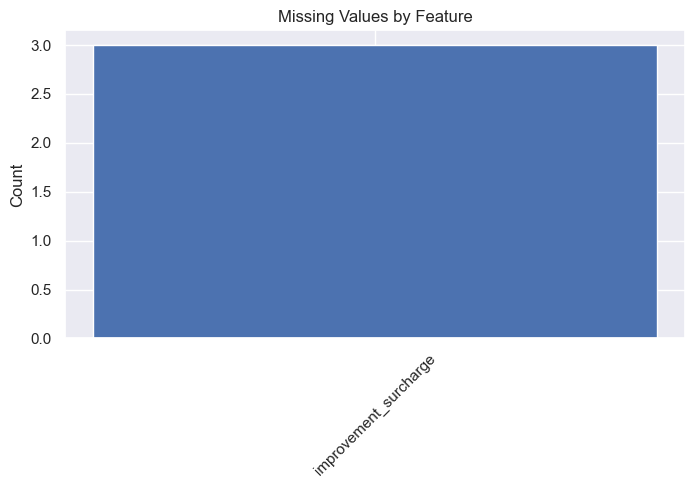

In [17]:
import matplotlib.pyplot as plt

missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["Missing Values"]
)

plt.title("Missing Values by Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Missing Values Analysis

### Summary

The dataset is exceptionally clean regarding missing values.

| Feature | Missing Values | Percentage |
|----------|---------------:|-----------:|
| improvement_surcharge | 3 | 0.000024% |

### Observations

- Only **3 missing values** were found across the entire dataset.
- All remaining features are **100% complete**.
- The missing percentage is statistically negligible.

### Decision

The missing values will be handled during the preprocessing stage without affecting the analysis.

## 2.2 Duplicate Records

In [18]:
duplicates = df.duplicated().sum()

duplicate_percentage = duplicates / len(df) * 100

print(f"Duplicate Rows       : {duplicates:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.6f}%")

Duplicate Rows       : 383
Duplicate Percentage : 0.003004%


In [19]:
df[df.duplicated()].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
248333,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
248334,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300143,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300144,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300145,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3


### Duplicate Records

### Summary

| Metric | Value |
|---------|------:|
| Duplicate Rows | **383** |
| Duplicate Percentage | **0.003004%** |

### Observations

- Only **383 duplicate records** were detected.
- Duplicate records represent approximately **0.003%** of the dataset.
- Most duplicated records appear to contain invalid values such as:
  - Zero trip distance
  - Zero pickup/dropoff coordinates

### Decision

Duplicate rows will be removed during the data cleaning phase. Since the duplication rate is extremely low, removing them will have no significant impact on the dataset.

## 2.3 Unique Values & Cardinality Analysis

In [20]:
unique_df = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique()
})

unique_df["Unique %"] = (
    unique_df["Unique Values"] / len(df) * 100
)

unique_df = unique_df.sort_values(
    "Unique Values",
    ascending=False
)

unique_df

,Data Type,Unique Values,Unique %
tpep_dropoff_datetime,str,2442163,19.155743
tpep_pickup_datetime,str,2438284,19.125317
dropoff_latitude,float64,87523,0.686509
pickup_latitude,float64,62748,0.492180
dropoff_longitude,float64,53297,0.418049
pickup_longitude,float64,35900,0.281591
total_amount,float64,11969,0.093882
trip_distance,float64,4350,0.034120
tip_amount,float64,3596,0.028206
fare_amount,float64,2053,0.016103


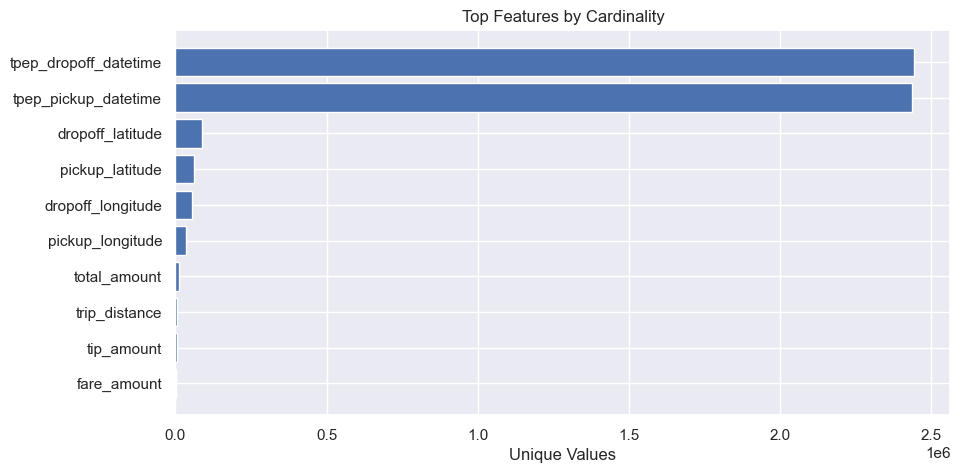

In [21]:
top_unique = unique_df.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_unique.index,
    top_unique["Unique Values"]
)

plt.title("Top Features by Cardinality")
plt.xlabel("Unique Values")

plt.gca().invert_yaxis()

plt.show()

### Unique Values & Cardinality Analysis

### Summary

The dataset contains a mixture of continuous, categorical, and temporal features.

### High Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| tpep_dropoff_datetime | 2,442,163 |
| tpep_pickup_datetime | 2,438,284 |
| dropoff_latitude | 87,523 |
| pickup_latitude | 62,748 |
| dropoff_longitude | 53,297 |
| pickup_longitude | 35,900 |

These features exhibit high cardinality and will require specialized preprocessing.

---

### Medium Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| total_amount | 11,969 |
| trip_distance | 4,350 |
| tip_amount | 3,596 |
| fare_amount | 2,053 |
| tolls_amount | 932 |

These are continuous numerical variables suitable for regression and time-series analysis.

---

### Low Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| passenger_count | 10 |
| RateCodeID | 7 |
| payment_type | 5 |
| VendorID | 2 |
| store_and_fwd_flag | 2 |

These variables will be treated as categorical features during preprocessing.

---

### Key Observations

- Datetime columns contain millions of unique timestamps and will be decomposed into meaningful temporal features.
- Geographic coordinates are continuous variables and require validation for invalid values.
- Several features naturally have low cardinality and are appropriate candidates for categorical encoding.

## 2.4 Invalid Values Detection

In [23]:
invalid_report = []

# Passenger Count <= 0
invalid_report.append({
    "Feature": "passenger_count <= 0",
    "Invalid Rows": (df["passenger_count"] <= 0).sum()
})

# Trip Distance <= 0
invalid_report.append({
    "Feature": "trip_distance <= 0",
    "Invalid Rows": (df["trip_distance"] <= 0).sum()
})

# Negative Fare
invalid_report.append({
    "Feature": "fare_amount < 0",
    "Invalid Rows": (df["fare_amount"] < 0).sum()
})

# Negative Tip
invalid_report.append({
    "Feature": "tip_amount < 0",
    "Invalid Rows": (df["tip_amount"] < 0).sum()
})

# Negative Total
invalid_report.append({
    "Feature": "total_amount < 0",
    "Invalid Rows": (df["total_amount"] < 0).sum()
})

# Invalid Latitude
invalid_report.append({
    "Feature": "Invalid Pickup Latitude",
    "Invalid Rows": (
        (df["pickup_latitude"] < -90) |
        (df["pickup_latitude"] > 90)
    ).sum()
})

invalid_report.append({
    "Feature": "Invalid Dropoff Latitude",
    "Invalid Rows": (
        (df["dropoff_latitude"] < -90) |
        (df["dropoff_latitude"] > 90)
    ).sum()
})

# Invalid Longitude
invalid_report.append({
    "Feature": "Invalid Pickup Longitude",
    "Invalid Rows": (
        (df["pickup_longitude"] < -180) |
        (df["pickup_longitude"] > 180)
    ).sum()
})

invalid_report.append({
    "Feature": "Invalid Dropoff Longitude",
    "Invalid Rows": (
        (df["dropoff_longitude"] < -180) |
        (df["dropoff_longitude"] > 180)
    ).sum()
})

invalid_report = pd.DataFrame(invalid_report)

invalid_report

,Feature,Invalid Rows
0,passenger_count <= 0,6565
1,trip_distance <= 0,79365
2,fare_amount < 0,4064
3,tip_amount < 0,79
4,total_amount < 0,4067
5,Invalid Pickup Latitude,1
6,Invalid Dropoff Latitude,2
7,Invalid Pickup Longitude,0
8,Invalid Dropoff Longitude,5


In [24]:
invalid_report["Percentage"] = (
    invalid_report["Invalid Rows"] / len(df) * 100
)

invalid_report

,Feature,Invalid Rows,Percentage
0,passenger_count <= 0,6565,0.051494
1,trip_distance <= 0,79365,0.622520
2,fare_amount < 0,4064,0.031877
3,tip_amount < 0,79,0.000620
4,total_amount < 0,4067,0.031901
5,Invalid Pickup Latitude,1,0.000008
6,Invalid Dropoff Latitude,2,0.000016
7,Invalid Pickup Longitude,0,0.000000
8,Invalid Dropoff Longitude,5,0.000039


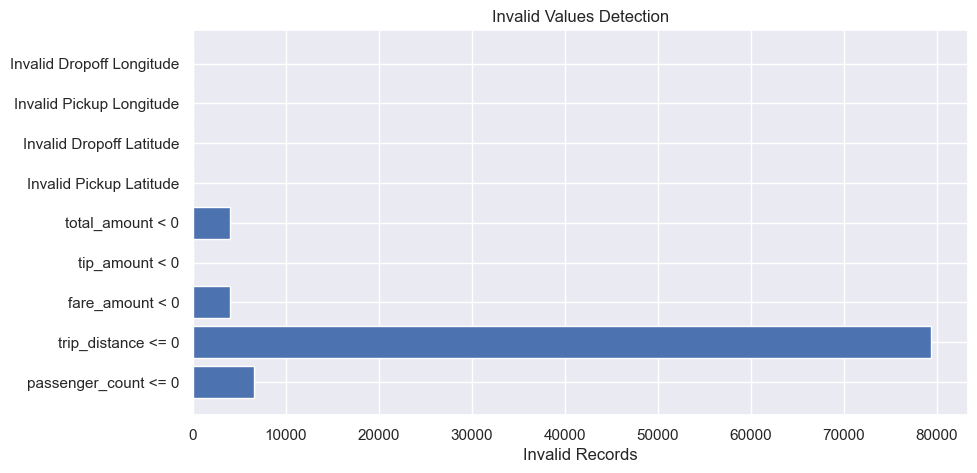

In [25]:
plt.figure(figsize=(10,5))

plt.barh(
    invalid_report["Feature"],
    invalid_report["Invalid Rows"]
)

plt.xlabel("Invalid Records")
plt.title("Invalid Values Detection")

plt.show()

In [26]:
df[df["fare_amount"] < 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
3831,2,2015-01-17 22:40:27,2015-01-17 22:43:04,1,0.11,-74.002357,40.739826,1,N,-74.001114,40.741108,4,-3.5,-0.5,-0.5,0.0,0.0,0.3,-4.8
4924,2,2015-01-15 17:33:24,2015-01-15 17:33:31,2,0.00,-73.982567,40.739799,1,N,-73.982567,40.739799,3,-2.5,-1.0,-0.5,-0.7,0.0,0.3,-5.0
10046,2,2015-01-16 16:00:45,2015-01-16 16:00:53,1,0.00,-73.937721,40.758194,1,N,-73.937721,40.758194,3,-2.5,-1.0,-0.5,0.0,0.0,0.3,-4.3
16703,2,2015-01-31 23:38:52,2015-01-31 23:38:54,2,0.00,0.000000,0.000000,2,N,0.000000,0.000000,2,-52.0,0.0,-0.5,0.0,0.0,0.3,-52.8
19953,2,2015-01-10 02:23:53,2015-01-10 02:23:58,2,0.00,0.000000,0.000000,5,N,0.000000,0.000000,1,-6.8,0.0,0.0,-1.0,0.0,0.3,-8.1


In [27]:
df[df["trip_distance"] <= 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
132,1,2015-01-15 10:26:16,2015-01-15 10:26:42,2,0.0,-73.987656,40.743645,5,N,-73.987488,40.743484,1,60.0,0.0,0.0,15.0,0.0,0.3,75.3
133,1,2015-01-15 10:26:17,2015-01-15 10:27:28,1,0.0,-73.946526,40.744991,1,N,-73.946526,40.744991,2,3.0,0.0,0.5,0.0,0.0,0.3,3.8
372,1,2015-01-01 01:08:56,2015-01-01 01:08:56,4,0.0,-73.980789,40.676605,1,Y,0.000000,0.000000,2,20.0,0.5,0.5,0.0,0.0,0.0,21.3
629,2,2015-01-25 17:45:15,2015-01-25 17:45:21,1,0.0,-73.975655,40.761318,2,N,0.000000,0.000000,1,52.0,0.0,0.5,20.0,0.0,0.3,72.8
707,1,2015-01-10 20:14:23,2015-01-10 20:14:36,1,0.0,-73.993271,40.748833,1,N,-73.993271,40.748833,3,2.5,0.5,0.5,0.0,0.0,0.3,3.8


In [28]:
df[
    (df["pickup_latitude"] > 90) |
    (df["pickup_latitude"] < -90)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
10833612,2,2015-01-18 23:43:40,2015-01-18 23:56:47,1,4.15,-73.98497,404.700012,1,N,-74.014519,40.717091,1,14.5,0.5,0.5,3.0,0.0,0.3,18.8


In [29]:
df[
    (df["dropoff_longitude"] < -180) |
    (df["dropoff_longitude"] > 180)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2128340,2,2015-01-19 21:12:55,2015-01-19 21:20:09,1,2.35,-73.956184,40.714127,1,N,-736.183350,40.737411,1,9.0,0.5,0.5,1.90,0.00,0.3,12.20
4511429,2,2015-01-08 19:56:04,2015-01-08 20:08:35,1,2.64,-73.942993,40.784092,2,N,-736.416687,40.787601,1,52.0,0.0,0.5,14.33,5.33,0.3,72.46
8918960,2,2015-01-15 00:31:06,2015-01-15 00:36:51,5,0.95,-73.990967,40.734180,1,N,-705.816650,40.741928,1,6.0,0.5,0.5,1.95,0.00,0.3,9.25
9753577,2,2015-01-25 01:02:15,2015-01-25 01:07:20,2,0.68,-73.982796,40.727146,1,N,-739.216675,40.726250,2,5.0,0.5,0.5,0.00,0.00,0.3,6.30
11836792,2,2015-01-17 02:46:28,2015-01-17 02:52:03,4,1.45,-74.009995,40.721222,1,N,-740.166687,40.735470,1,6.5,0.5,0.5,1.20,0.00,0.3,9.00


### Invalid Values Detection

### Objective

The objective of this step was to identify physically impossible or logically invalid values before starting the preprocessing phase.

### Validation Rules

| Feature | Expected Range |
|----------|----------------|
| passenger_count | > 0 |
| trip_distance | > 0 |
| fare_amount | >= 0 |
| tip_amount | >= 0 |
| total_amount | >= 0 |
| pickup_latitude | [-90, 90] |
| dropoff_latitude | [-90, 90] |
| pickup_longitude | [-180, 180] |
| dropoff_longitude | [-180, 180] |

### Results

| Validation Rule | Invalid Records | Percentage |
|-----------------|---------------:|-----------:|
| passenger_count <= 0 | 6,565 | 0.0515% |
| trip_distance <= 0 | 79,365 | 0.6225% |
| fare_amount < 0 | 4,064 | 0.0319% |
| tip_amount < 0 | 79 | 0.0006% |
| total_amount < 0 | 4,067 | 0.0319% |
| Invalid pickup latitude | 1 | 0.000008% |
| Invalid dropoff latitude | 2 | 0.000016% |
| Invalid pickup longitude | 0 | 0.000000% |
| Invalid dropoff longitude | 5 | 0.000039% |

### Observations

- Zero or negative trip distances represent the largest group of invalid records.
- Several trips contain non-positive passenger counts.
- A small number of trips have negative fare or total amounts, likely representing refunds, cancellations, or recording errors.
- Only a handful of records contain impossible geographic coordinates.
- Some records also contain `(0,0)` coordinates, which are technically within the valid geographic range but clearly invalid for NYC taxi trips.

### Conclusion

Although the percentage of invalid records is relatively small, these observations confirm that data cleaning is required before feature engineering and model development. The identified records will be handled during the preprocessing stage.

## 2.5 Outlier Detection

In [30]:
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount"
]

numeric_columns

['passenger_count',
 'trip_distance',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount']

In [31]:
outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": outliers,
        "Percentage": outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outliers",
    ascending=False
).reset_index(drop=True)

,Feature,Lower Bound,Upper Bound,Outliers,Percentage
0,passenger_count,-0.50,3.50,1405471,11.024179
1,trip_distance,-2.00,6.00,1259087,9.875978
2,total_amount,-4.05,28.51,1090560,8.554092
3,fare_amount,-4.00,24.00,1048995,8.228066
4,improvement_surcharge,0.30,0.30,716362,5.618972
5,tip_amount,-3.09,5.15,631614,4.954229
6,tolls_amount,0.00,0.00,540455,4.239200
7,mta_tax,0.50,0.50,52224,0.409633
8,extra,-0.75,1.25,717,0.005624


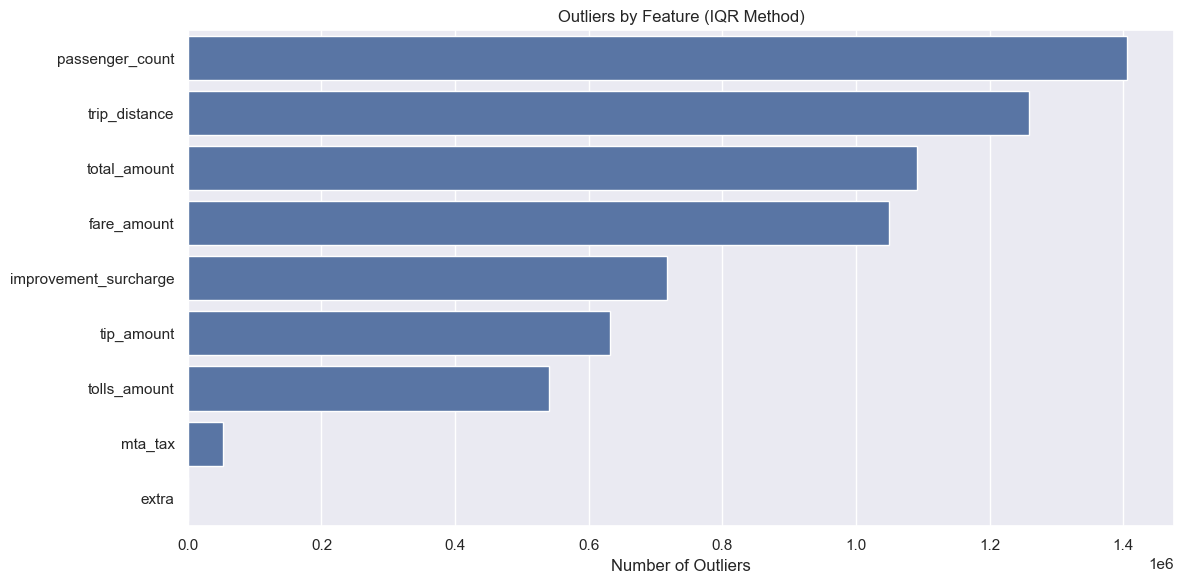

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=outlier_df.sort_values("Outliers", ascending=False),
    x="Outliers",
    y="Feature"
)

plt.title("Outliers by Feature (IQR Method)")
plt.xlabel("Number of Outliers")
plt.ylabel("")
plt.tight_layout()

plt.show()

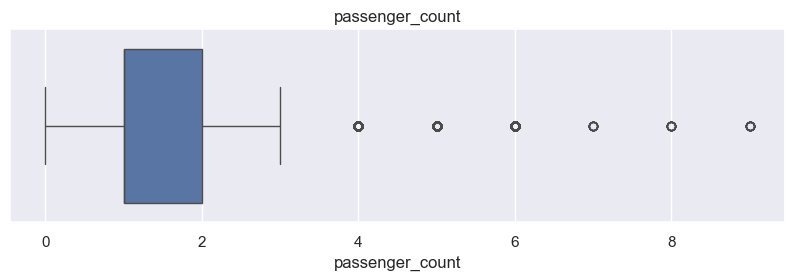

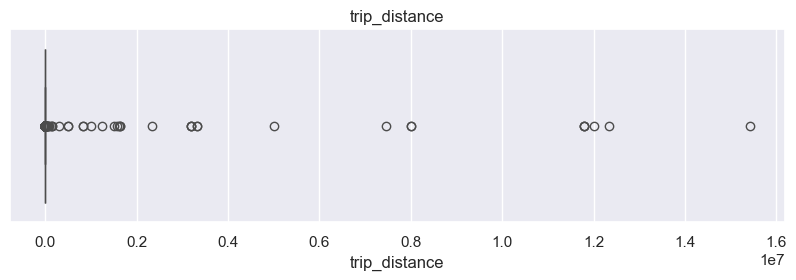

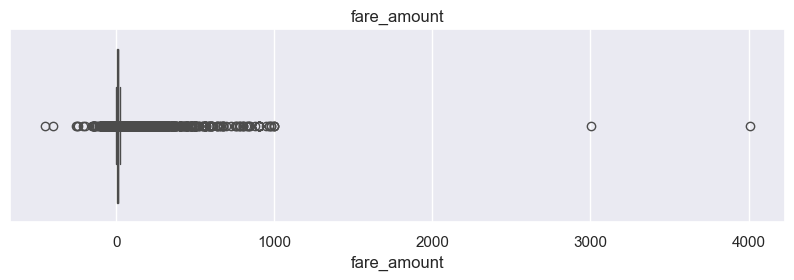

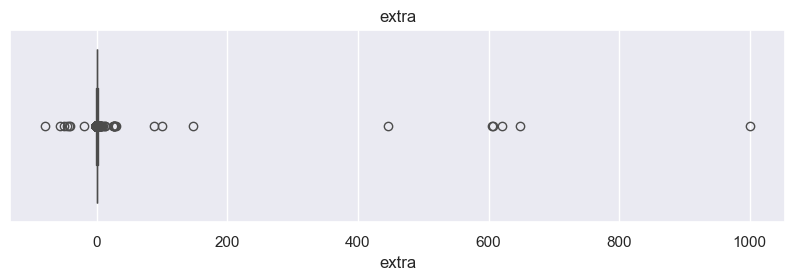

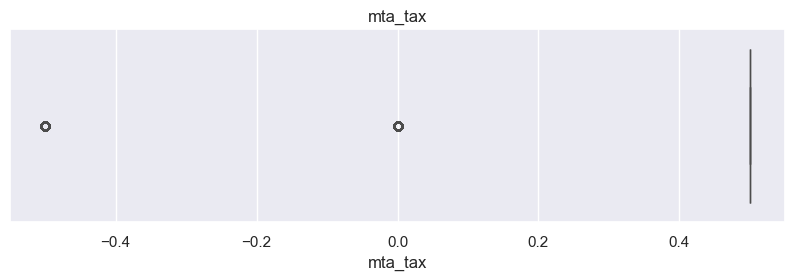

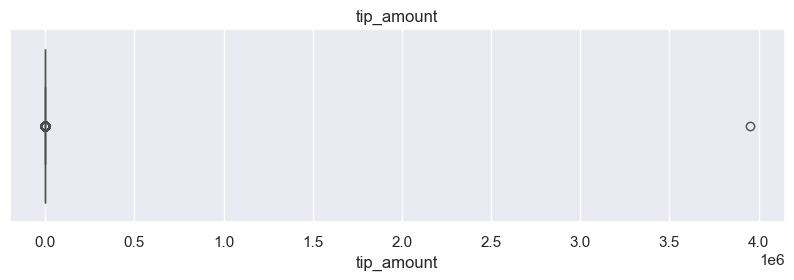

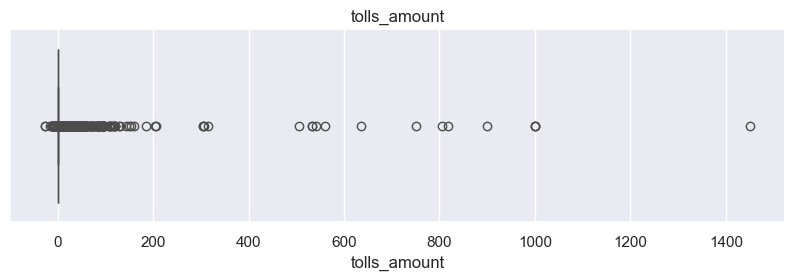

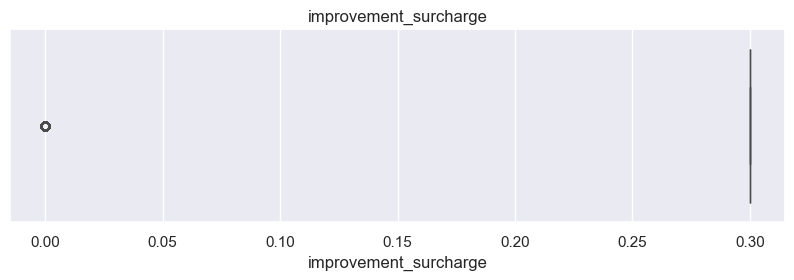

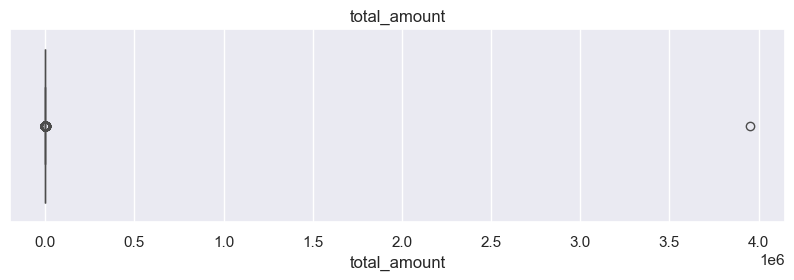

In [33]:
for col in numeric_columns:

    plt.figure(figsize=(10,2.5))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [34]:
feature = "trip_distance"

Q1 = df[feature].quantile(.25)
Q3 = df[feature].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[
    (df[feature] < lower) |
    (df[feature] > upper)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
5,1,2015-01-10 20:33:39,2015-01-10 20:53:52,1,9.00,-73.874374,40.774048,1,N,-73.986977,40.758194,1,27.0,0.5,0.5,6.70,5.33,0.3,40.33
8,1,2015-01-10 20:33:39,2015-01-10 21:11:35,3,18.20,-73.783043,40.644356,2,N,-73.987595,40.759357,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13
17,2,2015-01-15 19:05:40,2015-01-15 19:28:18,5,8.33,-73.863060,40.769581,1,N,-73.952713,40.785782,1,26.0,1.0,0.5,8.08,5.33,0.3,41.21
19,2,2015-01-15 19:05:41,2015-01-15 19:20:22,2,7.13,-73.874458,40.774010,1,N,-73.952377,40.718590,1,21.5,1.0,0.5,4.50,0.00,0.3,27.80
27,2,2015-01-15 19:05:42,2015-01-15 19:49:07,1,18.06,-73.786575,40.644127,2,N,-73.985603,40.743530,1,52.0,0.0,0.5,6.00,5.33,0.3,64.13


In [35]:
for col in numeric_columns:

    print("=" * 60)

    print(col)

    display(
        df[col].nlargest(5)
    )

passenger_count


5845       9
1216773    9
1441820    9
4065512    9
6590946    9
Name: passenger_count, dtype: int64

trip_distance


5052762     15420004.5
6623534     12331800.0
11022476    12000000.0
3318706     11800001.7
6160248     11800000.6
Name: trip_distance, dtype: float64

fare_amount


...

5189604     1450.09
2093033     1000.66
3353313      999.99
3590037      999.99
10883358     900.00
Name: tolls_amount, dtype: float64

improvement_surcharge


0    0.3
1    0.3
2    0.3
3    0.3
4    0.3
Name: improvement_surcharge, dtype: float64

total_amount


10862961    3950611.60
12477051       4009.30
1851068        3006.35
3590037        2999.97
3353313        1820.99
Name: total_amount, dtype: float64

In [36]:
for col in numeric_columns:

    print("=" * 60)

    print(col)

    display(
        df[col].nsmallest(5)
    )

passenger_count


1364    0
1898    0
2922    0
8185    0
9587    0
Name: passenger_count, dtype: int64

trip_distance


132    0.0
133    0.0
372    0.0
629    0.0
707    0.0
Name: trip_distance, dtype: float64

fare_amount


...

6574302    -26.00
10259094   -26.00
6035473    -16.00
667077     -11.75
3102514    -11.75
Name: tolls_amount, dtype: float64

improvement_surcharge


61    0.0
67    0.0
68    0.0
71    0.0
72    0.0
Name: improvement_surcharge, dtype: float64

total_amount


1034171    -450.30
1816134    -400.30
11509518   -255.80
4259203    -250.30
3409380    -242.55
Name: total_amount, dtype: float64

### 2.5 Outlier Detection

Outliers were identified using the **Interquartile Range (IQR)** method across all numerical features.

### Key Findings

Several numerical variables contain observations outside the IQR boundaries.

The highest percentages of detected outliers were:

| Feature | Outlier % |
|----------|-----------|
| passenger_count | 11.02% |
| trip_distance | 9.88% |
| total_amount | 8.55% |
| fare_amount | 8.23% |
| improvement_surcharge | 5.62% |
| tip_amount | 4.95% |
| tolls_amount | 4.24% |

### Observations

The analysis revealed two different categories of outliers:

- Legitimate business outliers such as:
  - Long-distance taxi trips
  - High fares
  - Large tips
  - High toll charges

- Data quality issues including:
  - Extremely large trip distances (millions of miles)
  - Unrealistically high fares and tips
  - Negative monetary values
  - Invalid surcharge values

### Conclusion

Since the IQR method identifies both legitimate extreme observations and erroneous records, **outliers will not be removed automatically** during the EDA phase.

Instead, data cleaning rules based on domain knowledge will be applied later during the preprocessing stage to distinguish between valid observations and corrupted records.

# 3. Exploratory Data Analysis (EDA)

## 3.1 Passenger Count Analysis

The `passenger_count` feature represents the number of passengers in each taxi trip.

In this section, we will:

- Examine the distribution of passenger counts.
- Identify the most common trip sizes.
- Detect unusual passenger counts.
- Calculate descriptive statistics.
- Visualize the distribution.Distribution

In [42]:
# ==========================================================
# Passenger Count - Descriptive Statistics
# ==========================================================

# Display summary statistics for passenger_count
df["passenger_count"].describe()

count    1.274899e+07
mean     1.681491e+00
std      1.337924e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [43]:
# ==========================================================
# Passenger Count Frequency
# ==========================================================

# Count each passenger value
passenger_counts = (
    df["passenger_count"]
    .value_counts()
    .sort_index()
)

passenger_counts

passenger_count
0       6565
1    8993870
2    1814594
3     528486
4     253228
5     697645
6     454568
7          9
8         10
9         11
Name: count, dtype: int64

In [44]:
# ==========================================================
# Passenger Count Percentage
# ==========================================================

# Calculate percentage for each passenger count
passenger_percentage = (
    df["passenger_count"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

passenger_percentage

passenger_count
0     0.051494
1    70.545767
2    14.233242
3     4.145318
4     1.986260
5     5.472161
6     3.565523
7     0.000071
8     0.000078
9     0.000086
Name: proportion, dtype: float64

In [45]:
# ==========================================================
# Passenger Count Summary Table
# ==========================================================

# Combine frequency and percentage into one table
passenger_summary = pd.DataFrame({
    "Count": passenger_counts,
    "Percentage": passenger_percentage
})

# Round percentages
passenger_summary["Percentage"] = passenger_summary["Percentage"].round(3)

passenger_summary

,Count,Percentage
passenger_count,,
0,6565,0.051
1,8993870,70.546
2,1814594,14.233
3,528486,4.145
4,253228,1.986
5,697645,5.472
6,454568,3.566
7,9,0.000
8,10,0.000


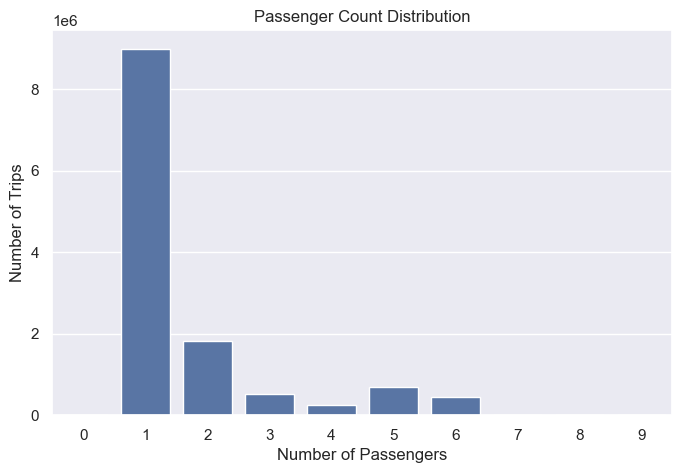

In [46]:
# ==========================================================
# Passenger Count Bar Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=passenger_summary.index,
    y=passenger_summary["Count"]
)

plt.title("Passenger Count Distribution")
plt.xlabel("Number of Passengers")
plt.ylabel("Number of Trips")

plt.show()

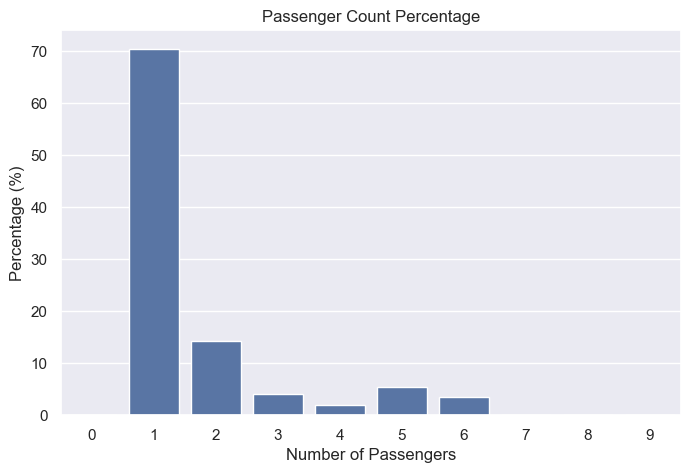

In [47]:
# ==========================================================
# Passenger Count Percentage Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=passenger_summary.index,
    y=passenger_summary["Percentage"]
)

plt.title("Passenger Count Percentage")
plt.xlabel("Number of Passengers")
plt.ylabel("Percentage (%)")

plt.show()

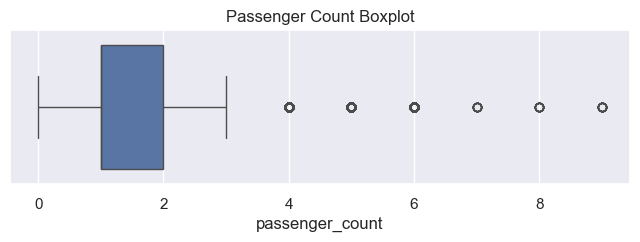

In [48]:
# ==========================================================
# Passenger Count Boxplot
# ==========================================================

plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["passenger_count"]
)

plt.title("Passenger Count Boxplot")

plt.show()

### Findings

#### Passenger Count Distribution

The passenger count analysis reveals a highly imbalanced distribution across taxi trips.

**Key observations:**

- Approximately **70.55%** of all trips involve **one passenger**, making solo travel the dominant travel pattern in the dataset.

- Around **14.23%** of trips contain **two passengers**, representing the second most common trip type.

- Trips with **three or four passengers** are relatively uncommon, accounting for only **4.15%** and **1.99%**, respectively.

- Surprisingly, trips with **five (5.47%)** and **six passengers (3.57%)** occur more frequently than trips with three or four passengers. This may reflect larger groups using shared taxi services or airport transportation.

- Passenger counts greater than six (7–9 passengers) are extremely rare, with only **30 observations** across more than **12.7 million trips**, indicating potential data entry errors or exceptional cases.

- A small number of trips (**6,565 records**, approximately **0.05%**) contain **zero passengers**, which were previously identified as invalid records during the data quality assessment.

#### Distribution Shape

The boxplot confirms that the passenger count distribution is **strongly right-skewed**.

Most observations are concentrated between **one and two passengers**, while passenger counts greater than three appear as statistical outliers. However, these values are operationally valid and represent legitimate larger-group trips rather than erroneous data.

#### Conclusion

The analysis indicates that the vast majority of NYC taxi rides are taken by one or two passengers. The `passenger_count` feature has a highly discrete distribution and does not require transformation at this stage. Invalid zero-passenger trips will be handled later during the data cleaning phase.

## 3.2 Trip Distance Analysis

The `trip_distance` feature represents the distance traveled during each taxi trip in miles.

In this section, we will:

- Explore the statistical distribution of trip distances.
- Identify the most common trip lengths.
- Visualize the distribution.
- Examine skewness and extreme values.
- Understand how trip distance varies across the dataset.

In [49]:
# ==========================================================
# Trip Distance - Descriptive Statistics
# ==========================================================

# Display summary statistics
df["trip_distance"].describe()

count    1.274899e+07
mean     1.345913e+01
std      9.844094e+03
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.000000e+00
max      1.542000e+07
Name: trip_distance, dtype: float64

In [50]:
# ==========================================================
# Trip Distance Percentiles
# ==========================================================

# Calculate important percentiles
distance_percentiles = (
    df["trip_distance"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Distance (Miles)")
)

distance_percentiles

,Distance (Miles)
0.25,1.00
0.50,1.68
0.75,3.00
0.90,5.99
0.95,9.66
0.99,18.22


In [58]:
# ==========================================================
# Trip Distance Distribution
# ==========================================================

# Sample data for faster visualization
distance_sample = df["trip_distance"].sample(
    n=200000,
    random_state=42
)

print(f"Sample Size: {len(distance_sample):,}")

Sample Size: 200,000


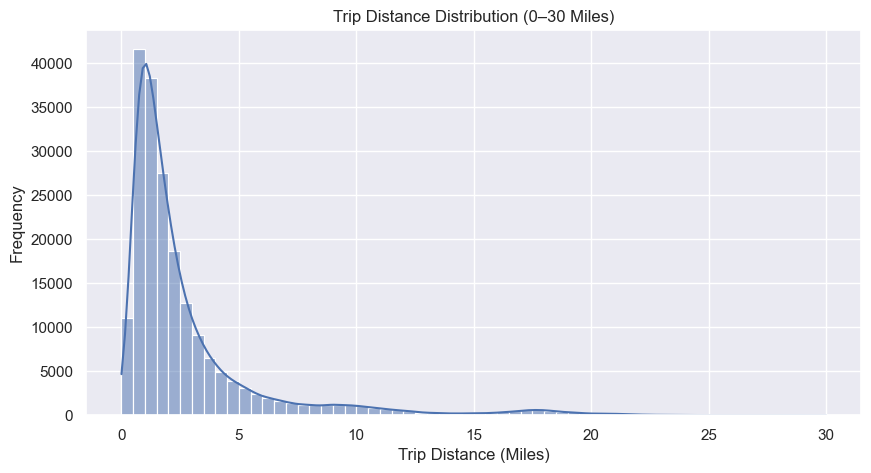

In [56]:
# ==========================================================
# Trip Distance Distribution (Valid Trips Only)
# ==========================================================

# Keep trips between 0 and 30 miles for visualization
distance_plot = df.loc[
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 30),
    "trip_distance"
].sample(
    n=200000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    distance_plot,
    bins=60,
    kde=True
)

plt.title("Trip Distance Distribution (0–30 Miles)")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Frequency")

plt.show()

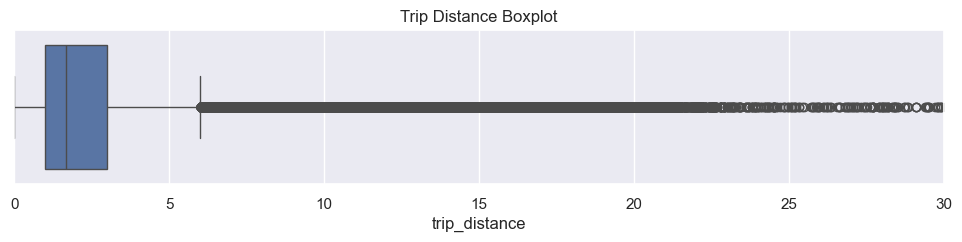

In [ ]:
# ==========================================================
# Trip Distance Boxplot
# ==========================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=distance_sample
)

plt.xlim(0,30)

plt.title("Trip Distance Boxplot")

plt.show()

In [54]:
# ==========================================================
# Trip Distance Summary
# ==========================================================

trip_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["trip_distance"].mean(),
        df["trip_distance"].median(),
        df["trip_distance"].std(),
        df["trip_distance"].min(),
        df["trip_distance"].max()
    ]

})

trip_summary

,Statistic,Value
0,Mean,1.345913e+01
1,Median,1.680000e+00
2,Std,9.844094e+03
3,Minimum,0.000000e+00
4,Maximum,1.542000e+07


In [55]:
# ==========================================================
# Long Distance Trips
# ==========================================================

# Trips longer than 30 miles
long_trips = df[df["trip_distance"] > 30]

print(f"Trips > 30 Miles : {len(long_trips):,}")

long_trips.head()

Trips > 30 Miles : 3,390


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2110,2,2015-01-06 11:49:51,2015-01-06 13:03:03,1,41.94,-73.939407,40.750420,5,N,-74.393951,40.531219,1,190.0,0.0,0.0,0.00,14.75,0.3,205.05
5233,1,2015-01-11 03:28:03,2015-01-11 03:42:48,1,34.30,-74.003983,40.752075,1,N,-73.971634,40.785339,1,2.5,0.5,0.5,1.00,10.30,0.3,15.10
7584,2,2015-01-16 03:04:37,2015-01-16 03:49:08,4,36.07,-73.785454,40.645649,5,N,-74.198837,40.674656,2,135.5,0.0,0.0,0.00,9.75,0.3,145.55
11971,2,2015-01-24 00:19:53,2015-01-24 01:06:45,1,36.54,-73.790344,40.646523,5,N,-73.710472,41.077820,1,150.0,0.0,0.0,30.06,0.00,0.3,180.36
14644,1,2015-01-18 07:36:47,2015-01-18 08:48:42,1,33.60,0.000000,0.000000,2,N,0.000000,0.000000,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13


### Findings

#### Trip Distance Distribution

The trip distance analysis indicates that most NYC taxi trips are relatively short.

**Key observations**

- The median trip distance is **1.68 miles**, indicating that half of all taxi trips are shorter than two miles.

- The first quartile is **1.0 mile**, while the third quartile is **3.0 miles**, meaning that **75% of all trips are three miles or less**.

- Even the **95th percentile is only 9.66 miles**, showing that long-distance trips are uncommon.

- Only **1% of trips exceed 18.22 miles**, confirming that the overwhelming majority of taxi rides occur within short urban distances.

- A total of **3,390 trips** exceed **30 miles**, representing only a tiny fraction of the dataset. These trips are likely airport transfers or long intercity rides, although some records may still represent data quality issues.

#### Distribution Shape

The distribution is **extremely right-skewed**.

Most observations are concentrated between **1 and 3 miles**, while a very small number of extremely long trips create a long right tail.

#### Mean vs Median

The mean trip distance (**13.46 miles**) is substantially higher than the median (**1.68 miles**).

This large discrepancy is caused by a handful of unrealistic values, including trips with distances reaching **15.42 million miles**.

These extreme observations heavily inflate the average and should not be considered representative of typical taxi trips.

#### Conclusion

The trip distance feature exhibits a highly skewed distribution with a small number of extreme values.

For subsequent analysis and visualization, it is preferable to focus on realistic trip distances (e.g., 0–30 miles) while handling erroneous extreme values during the data cleaning stage.

## 3.3 Fare Amount Analysis

The `fare_amount` feature represents the base fare charged for each taxi trip before additional fees, tolls, and tips.

In this section, we will:

- Examine the statistical distribution of fares.
- Explore common fare ranges.
- Visualize fare distribution.
- Investigate extreme values.
- Understand the overall pricing behavior.

In [59]:
# ==========================================================
# Fare Amount - Descriptive Statistics
# ==========================================================

# Display summary statistics
df["fare_amount"].describe()

count    1.274899e+07
mean     1.190566e+01
std      1.030254e+01
min     -4.500000e+02
25%      6.500000e+00
50%      9.000000e+00
75%      1.350000e+01
max      4.008000e+03
Name: fare_amount, dtype: float64

In [60]:
# ==========================================================
# Fare Amount Percentiles
# ==========================================================

# Calculate important fare percentiles
fare_percentiles = (
    df["fare_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Fare ($)")
)

fare_percentiles

,Fare ($)
0.25,6.5
0.50,9.0
0.75,13.5
0.90,22.0
0.95,31.0
0.99,52.0


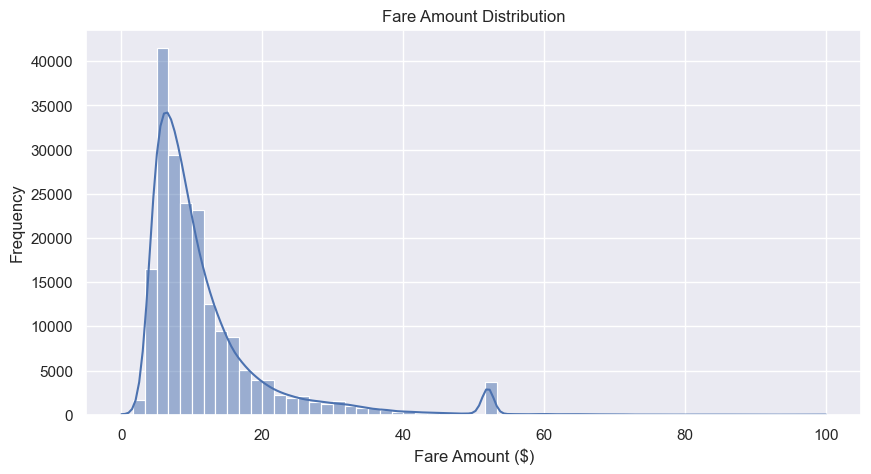

In [61]:
# ==========================================================
# Fare Distribution
# ==========================================================

# Sample realistic fares for visualization
fare_sample = df.loc[
    (df["fare_amount"] >= 0) &
    (df["fare_amount"] <= 100),
    "fare_amount"
].sample(
    n=200000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    fare_sample,
    bins=60,
    kde=True
)

plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")

plt.show()

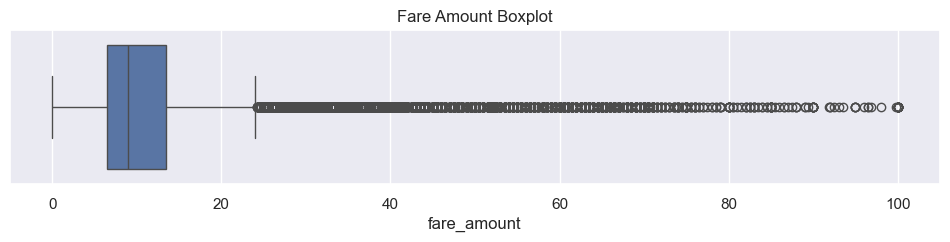

In [62]:
# ==========================================================
# Fare Amount Boxplot
# ==========================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=fare_sample
)

plt.title("Fare Amount Boxplot")

plt.show()

In [63]:
# ==========================================================
# Fare Amount Summary
# ==========================================================

fare_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["fare_amount"].mean(),
        df["fare_amount"].median(),
        df["fare_amount"].std(),
        df["fare_amount"].min(),
        df["fare_amount"].max()
    ]

})

fare_summary

,Statistic,Value
0,Mean,11.905659
1,Median,9.000000
2,Std,10.302537
3,Minimum,-450.000000
4,Maximum,4008.000000


In [64]:
# ==========================================================
# Fare Amount Skewness
# ==========================================================

# Calculate skewness
fare_skewness = df["fare_amount"].skew()

print(f"Fare Amount Skewness : {fare_skewness:.2f}")

Fare Amount Skewness : 12.62


In [65]:
# ==========================================================
# High Fare Trips
# ==========================================================

# Trips with fares above $100
high_fares = df[df["fare_amount"] > 100]

print(f"Trips > $100 : {len(high_fares):,}")

high_fares.head()

Trips > $100 : 5,721


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1278,1,2015-01-26 13:33:53,2015-01-26 13:35:28,1,0.00,-74.035408,40.744484,5,N,-74.035461,40.744503,1,149.0,0.0,0.0,0.00,0.00,0.3,149.30
2110,2,2015-01-06 11:49:51,2015-01-06 13:03:03,1,41.94,-73.939407,40.750420,5,N,-74.393951,40.531219,1,190.0,0.0,0.0,0.00,14.75,0.3,205.05
4879,2,2015-01-26 14:19:25,2015-01-26 16:37:03,1,25.42,-73.977257,40.742832,3,N,-74.177460,40.690643,1,115.5,0.0,0.0,10.00,11.75,0.3,137.55
6545,1,2015-01-04 15:14:15,2015-01-04 15:16:10,1,0.10,-73.673126,40.982090,5,N,-73.671165,40.983475,1,143.0,0.0,0.0,37.55,7.00,0.0,187.85
7584,2,2015-01-16 03:04:37,2015-01-16 03:49:08,4,36.07,-73.785454,40.645649,5,N,-74.198837,40.674656,2,135.5,0.0,0.0,0.00,9.75,0.3,145.55


In [66]:
# ==========================================================
# Fare Range Distribution
# ==========================================================

fare_bins = [0, 10, 20, 30, 50, 100, float("inf")]
fare_labels = [
    "$0–10",
    "$10–20",
    "$20–30",
    "$30–50",
    "$50–100",
    ">$100"
]

fare_groups = pd.cut(
    df["fare_amount"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

fare_distribution = (
    fare_groups
    .value_counts()
    .sort_index()
    .to_frame("Trips")
)

fare_distribution["Percentage"] = (
    fare_distribution["Trips"] / len(df) * 100
).round(2)

fare_distribution

,Trips,Percentage
fare_amount,,
$0–10,7639035,59.92
$10–20,3645475,28.59
$20–30,788090,6.18
$30–50,380807,2.99
$50–100,285794,2.24
>$100,5721,0.04


### Fare Amount Analysis — Key Findings

- The median fare was **$9.00**, indicating that half of all taxi trips cost $9 or less.

- The mean fare was approximately **$11.91**, which was higher than the median. This difference indicates a positively skewed fare distribution caused by a relatively small number of high-fare trips.

- Fare percentiles showed that:
  - 75% of trips had fares of **$13.50 or less**.
  - 90% had fares of **$22.00 or less**.
  - 95% had fares of **$31.00 or less**.
  - 99% had fares of **$52.00 or less**.

- Approximately **59.92%** of all trips had fares between **$0 and $10**, while **28.59%** had fares between **$10 and $20**. Therefore, approximately **88.51%** of trips had fares below or equal to $20.

- The fare distribution was strongly right-skewed, with a skewness value of **12.62**. Most trips were concentrated in the lower fare ranges, while a small number of expensive trips created a long right tail.

- A noticeable concentration appeared near **$52**, which may be associated with a fixed-fare trip category. This pattern will be investigated later using variables such as `RateCodeID`, trip distance, and pickup/dropoff locations.

- Only **5,721 trips (0.04%)** had fares above $100. These records should not be removed automatically because some may represent legitimate long-distance or special-rate trips.

- Negative fare values and extremely high fares were detected. These records require further investigation during the data-cleaning stage.

### Business Insight

The taxi market was dominated by relatively low-cost trips. Nearly nine out of every ten trips had a base fare of $20 or less, suggesting that typical taxi demand mainly consisted of short to medium-distance urban journeys.

## 3.4 Total Amount Analysis

The `total_amount` feature represents the final recorded amount associated with each taxi trip, including the base fare, additional charges, taxes, tips, tolls, and improvement surcharge.

This analysis aims to:

- Examine the statistical distribution of total trip amounts.
- Identify the typical amount associated with a taxi trip.
- Measure the spread and skewness of the distribution.
- Examine important percentiles.
- Identify negative, zero, and unusually high total amounts.
- Compare the total amount with the base fare.

In [67]:
# ============================================================
# Total Amount - Descriptive Statistics
# ============================================================

# Display summary statistics for the total trip amount
df["total_amount"].describe()

count    1.274899e+07
mean     1.510829e+01
std      1.106503e+03
min     -4.503000e+02
25%      8.160000e+00
50%      1.116000e+01
75%      1.630000e+01
max      3.950612e+06
Name: total_amount, dtype: float64

In [68]:
# ============================================================
# Total Amount Percentiles
# ============================================================

# Calculate important total amount percentiles
total_percentiles = (
    df["total_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Total Amount ($)")
)

# Display the percentile table
total_percentiles

,Total Amount ($)
0.25,8.16
0.50,11.16
0.75,16.30
0.90,26.00
0.95,39.17
0.99,68.13


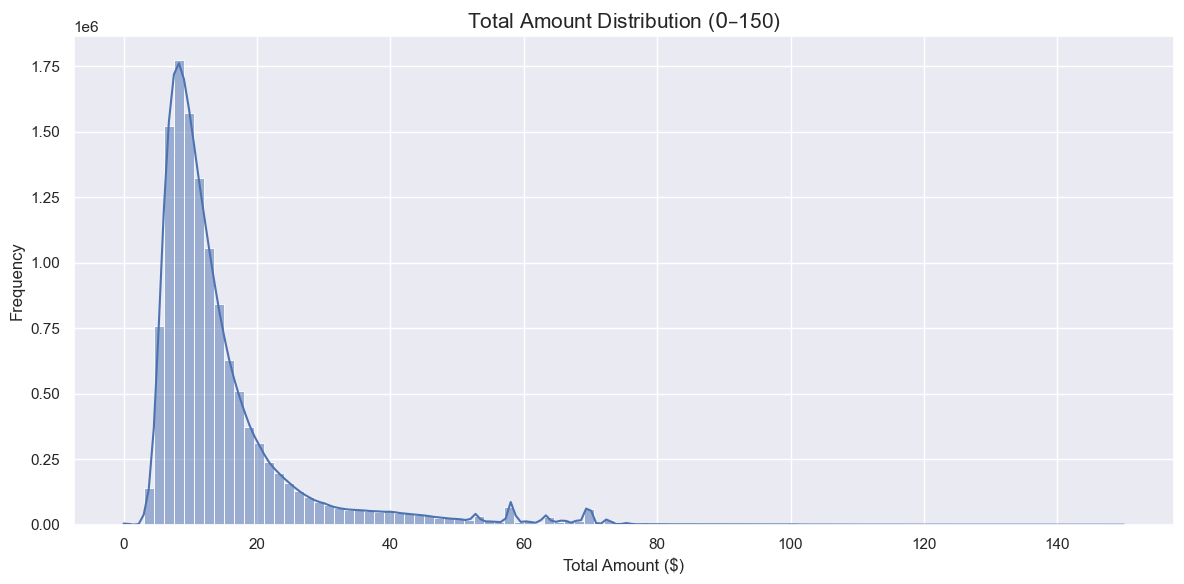

In [69]:
# ============================================================
# Total Amount Distribution
# ============================================================

# Plot the distribution using only total amounts
# between $0 and $150 for better visualization
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df[
        (df["total_amount"] >= 0) &
        (df["total_amount"] <= 150)
    ],
    x="total_amount",
    bins=100,
    kde=True
)

# Add chart title and axis labels
plt.title(
    "Total Amount Distribution ($0–$150)",
    fontsize=15
)

plt.xlabel("Total Amount ($)")
plt.ylabel("Frequency")

# Improve chart layout
plt.tight_layout()

plt.show()

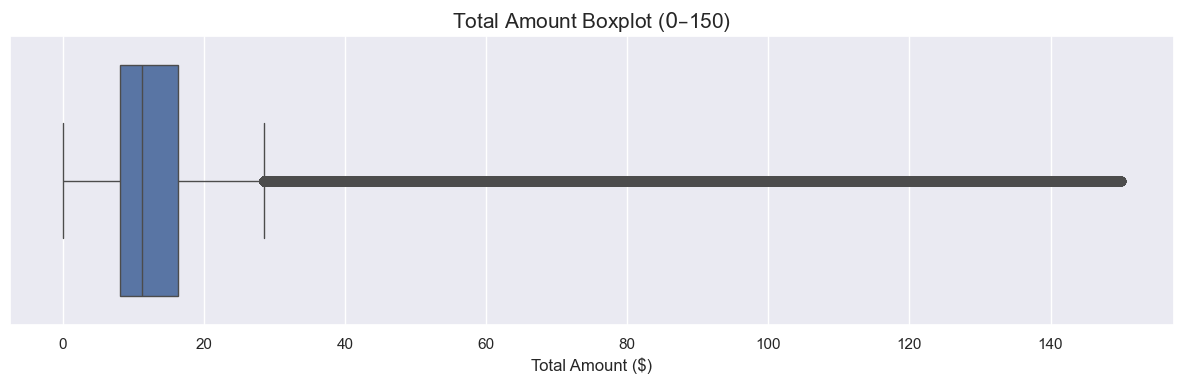

In [70]:
# ============================================================
# Total Amount Boxplot
# ============================================================

# Display total amounts between $0 and $150
# to make the main distribution visible
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=df[
        (df["total_amount"] >= 0) &
        (df["total_amount"] <= 150)
    ],
    x="total_amount"
)

# Add chart title and axis label
plt.title(
    "Total Amount Boxplot ($0–$150)",
    fontsize=15
)

plt.xlabel("Total Amount ($)")

# Improve chart layout
plt.tight_layout()

plt.show()

In [71]:
# ============================================================
# Total Amount Summary
# ============================================================

# Create a summary table containing important statistics
total_summary = pd.DataFrame({
    
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    
    "Value": [
        df["total_amount"].mean(),
        df["total_amount"].median(),
        df["total_amount"].std(),
        df["total_amount"].min(),
        df["total_amount"].max()
    ]
})

# Display the summary table
total_summary

,Statistic,Value
0,Mean,1.510829e+01
1,Median,1.116000e+01
2,Standard Deviation,1.106503e+03
3,Minimum,-4.503000e+02
4,Maximum,3.950612e+06


In [72]:
# ============================================================
# Total Amount Skewness
# ============================================================

# Calculate the skewness of the total amount distribution
total_skewness = df["total_amount"].skew()

# Display the result
print(
    f"Total Amount Skewness : {total_skewness:.2f}"
)

Total Amount Skewness : 3569.89


In [73]:
# ============================================================
# Invalid Total Amount Values
# ============================================================

# Count trips with negative total amounts
negative_total = (
    df["total_amount"] < 0
).sum()

# Count trips with zero total amounts
zero_total = (
    df["total_amount"] == 0
).sum()

# Calculate their percentages
negative_total_percentage = (
    negative_total / len(df)
) * 100

zero_total_percentage = (
    zero_total / len(df)
) * 100

# Display the results
print(
    f"Negative Total Amounts : "
    f"{negative_total:,} "
    f"({negative_total_percentage:.4f}%)"
)

print(
    f"Zero Total Amounts     : "
    f"{zero_total:,} "
    f"({zero_total_percentage:.4f}%)"
)

Negative Total Amounts : 4,067 (0.0319%)
Zero Total Amounts     : 1,194 (0.0094%)


In [74]:
# ============================================================
# Total Amount Ranges
# ============================================================

# Define total amount intervals
total_bins = [
    0,
    10,
    20,
    30,
    50,
    100,
    float("inf")
]

# Define labels for each interval
total_labels = [
    "$0–10",
    "$10–20",
    "$20–30",
    "$30–50",
    "$50–100",
    ">$100"
]

# Group non-negative total amounts into ranges
total_ranges = pd.cut(
    
    df.loc[
        df["total_amount"] >= 0,
        "total_amount"
    ],
    
    bins=total_bins,
    labels=total_labels,
    include_lowest=True,
    right=True
)

# Count trips in each range
total_range_counts = (
    total_ranges
    .value_counts()
    .sort_index()
)

# Calculate the percentage of trips in each range
total_range_percentage = (
    total_range_counts /
    total_range_counts.sum()
) * 100

# Combine counts and percentages into one table
total_range_summary = pd.DataFrame({
    
    "Trips": total_range_counts,
    
    "Percentage": (
        total_range_percentage.round(2)
    )
})

# Display the final table
total_range_summary

,Trips,Percentage
total_amount,,
$0–10,5367863,42.12
$10–20,5265349,41.31
$20–30,1111753,8.72
$30–50,622516,4.88
$50–100,364749,2.86
>$100,12689,0.10


### Total Amount Analysis — Key Findings

- The median total trip amount was **$11.16**, indicating that half of all taxi trips had a final recorded amount of $11.16 or less.

- The mean total amount was approximately **$15.11**, which was higher than the median. This difference indicates a positively skewed distribution caused by a relatively small number of high-value trips.

- Total amount percentiles showed that:
  - 75% of trips had total amounts of **$16.30 or less**.
  - 90% had total amounts of **$26.00 or less**.
  - 95% had total amounts of **$39.17 or less**.
  - 99% had total amounts of **$68.13 or less**.

- Approximately **42.12%** of trips had total amounts between **$0 and $10**, while **41.31%** had total amounts between **$10 and $20**. Therefore, approximately **83.43%** of trips had final amounts of $20 or less.

- Only **12,689 trips (0.10%)** had total amounts greater than $100, indicating that very expensive trips represented a small fraction of the dataset.

- The total amount distribution was extremely right-skewed, with a skewness value of **3569.89**. This unusually high value was heavily influenced by extreme observations, including a maximum recorded total amount of approximately **$3.95 million**.

- The extreme maximum value is unlikely to represent a normal taxi transaction and should be investigated as a potential data-quality issue during the data-cleaning stage.

- The standard deviation was approximately **$1,106.50**, but this value was strongly inflated by extreme observations. Therefore, the median and percentiles provide more reliable descriptions of a typical taxi trip than the mean and standard deviation.

- A total of **4,067 records (0.0319%)** contained negative total amounts, while **1,194 records (0.0094%)** had total amounts equal to zero.

- Negative and zero total amounts may represent refunds, cancelled trips, transaction adjustments, or recording errors. Their exact cause cannot be determined from the available variables and requires further investigation.

### Business Insight

Taxi trips were generally low-cost transactions. Approximately **83% of all trips had a final recorded amount of $20 or less**, while only 1% exceeded approximately $68.

The typical passenger paid approximately **$11**, although additional charges, tips, tolls, and a small number of unusually expensive records increased the overall average to approximately **$15**.

## 3.5 Tip Amount Analysis

The `tip_amount` feature represents the recorded tip associated with each taxi trip.

This analysis aims to:

- Examine the statistical distribution of recorded tip amounts.
- Determine the percentage of trips with and without recorded tips.
- Estimate the typical tip amount among trips with positive tips.
- Examine important tip amount percentiles.
- Identify negative, zero, and unusually high tip values.
- Analyze the distribution of positive tip amounts.
- Prepare for a later investigation of the relationship between tipping behavior and payment type.

In [75]:
# ============================================================
# Tip Amount - Descriptive Statistics
# ============================================================

# Display summary statistics for all recorded tip amounts
df["tip_amount"].describe()

count    1.274899e+07
mean     1.853814e+00
std      1.106432e+03
min     -9.242000e+01
25%      0.000000e+00
50%      1.000000e+00
75%      2.060000e+00
max      3.950589e+06
Name: tip_amount, dtype: float64

In [76]:
# ============================================================
# Tip Amount Percentiles - All Trips
# ============================================================

# Calculate important tip amount percentiles
# using all trips, including zero-tip records
tip_percentiles = (
    df["tip_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Tip Amount ($)")
)

# Display the percentile table
tip_percentiles

,Tip Amount ($)
0.25,0.00
0.50,1.00
0.75,2.06
0.90,3.56
0.95,5.12
0.99,11.30


In [77]:
# ============================================================
# Trips With and Without Positive Tips
# ============================================================

# Count trips with a positive recorded tip
positive_tip_trips = (
    df["tip_amount"] > 0
).sum()

# Count trips with no recorded tip
zero_tip_trips = (
    df["tip_amount"] == 0
).sum()

# Count trips with negative recorded tips
negative_tip_trips = (
    df["tip_amount"] < 0
).sum()

# Calculate percentages using the complete dataset
positive_tip_percentage = (
    positive_tip_trips / len(df)
) * 100

zero_tip_percentage = (
    zero_tip_trips / len(df)
) * 100

negative_tip_percentage = (
    negative_tip_trips / len(df)
) * 100

# Display the results
print(
    f"Trips With Positive Tips : "
    f"{positive_tip_trips:,} "
    f"({positive_tip_percentage:.2f}%)"
)

print(
    f"Trips With Zero Tips     : "
    f"{zero_tip_trips:,} "
    f"({zero_tip_percentage:.2f}%)"
)

print(
    f"Trips With Negative Tips : "
    f"{negative_tip_trips:,} "
    f"({negative_tip_percentage:.4f}%)"
)

Trips With Positive Tips : 7,611,140 (59.70%)
Trips With Zero Tips     : 5,137,767 (40.30%)
Trips With Negative Tips : 79 (0.0006%)


In [78]:
# ============================================================
# Positive Tip Trips
# ============================================================

# Select trips with positive recorded tip amounts
positive_tips = df.loc[
    df["tip_amount"] > 0,
    "tip_amount"
]

# Display descriptive statistics
# for positive recorded tips only
positive_tips.describe()

count    7.611140e+06
mean     3.105294e+00
std      1.431982e+03
min      1.000000e-02
25%      1.300000e+00
50%      2.000000e+00
75%      2.900000e+00
max      3.950589e+06
Name: tip_amount, dtype: float64

In [79]:
# ============================================================
# Positive Tip Amount Percentiles
# ============================================================

# Calculate important percentiles
# using positive recorded tips only
positive_tip_percentiles = (
    positive_tips
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Positive Tip Amount ($)")
)

# Display the percentile table
positive_tip_percentiles

,Positive Tip Amount ($)
0.25,1.30
0.50,2.00
0.75,2.90
0.90,4.85
0.95,7.00
0.99,11.63


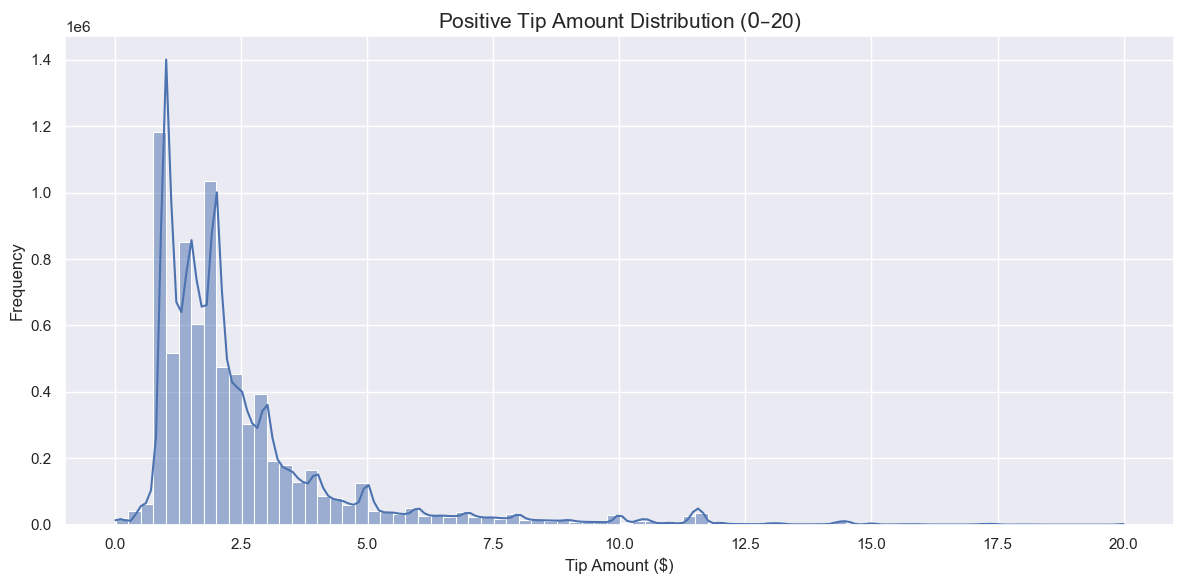

In [80]:
# ============================================================
# Positive Tip Amount Distribution
# ============================================================

# Plot positive tip amounts up to $20
# to make the main distribution clearly visible
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df[
        (df["tip_amount"] > 0) &
        (df["tip_amount"] <= 20)
    ],
    x="tip_amount",
    bins=80,
    kde=True
)

# Add chart title and axis labels
plt.title(
    "Positive Tip Amount Distribution ($0–$20)",
    fontsize=15
)

plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")

# Improve chart layout
plt.tight_layout()

plt.show()

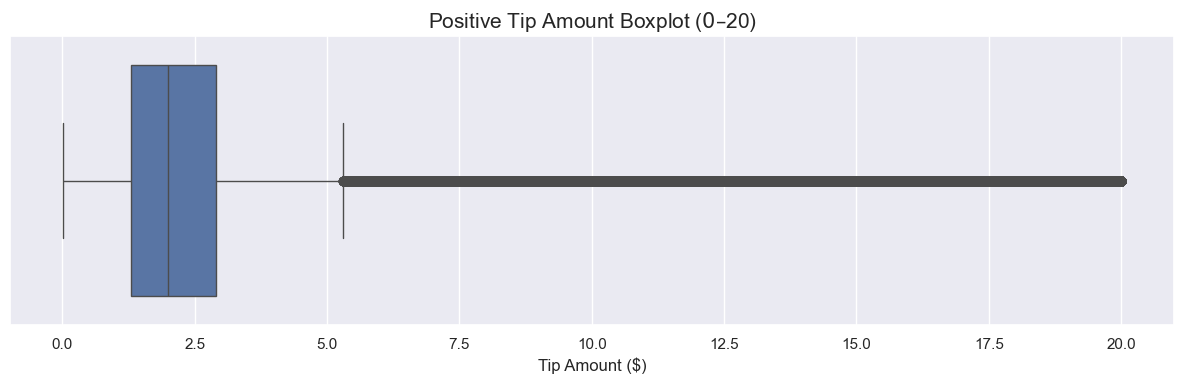

In [81]:
# ============================================================
# Positive Tip Amount Boxplot
# ============================================================

# Display positive tips up to $20
# to prevent extreme values from compressing the chart
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=df[
        (df["tip_amount"] > 0) &
        (df["tip_amount"] <= 20)
    ],
    x="tip_amount"
)

# Add chart title and axis label
plt.title(
    "Positive Tip Amount Boxplot ($0–$20)",
    fontsize=15
)

plt.xlabel("Tip Amount ($)")

# Improve chart layout
plt.tight_layout()

plt.show()

In [82]:
# ============================================================
# Positive Tip Amount Summary
# ============================================================

# Create a summary table for positive recorded tips
positive_tip_summary = pd.DataFrame({
    
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    
    "Value": [
        positive_tips.mean(),
        positive_tips.median(),
        positive_tips.std(),
        positive_tips.min(),
        positive_tips.max()
    ]
})

# Display the summary table
positive_tip_summary

,Statistic,Value
0,Mean,3.105294e+00
1,Median,2.000000e+00
2,Standard Deviation,1.431982e+03
3,Minimum,1.000000e-02
4,Maximum,3.950589e+06


In [83]:
# ============================================================
# Tip Amount Skewness
# ============================================================

# Calculate skewness using all recorded tip amounts
all_tip_skewness = (
    df["tip_amount"].skew()
)

# Calculate skewness using positive tips only
positive_tip_skewness = (
    positive_tips.skew()
)

# Display the results
print(
    f"All Tip Amounts Skewness      : "
    f"{all_tip_skewness:.2f}"
)

print(
    f"Positive Tip Amounts Skewness : "
    f"{positive_tip_skewness:.2f}"
)

All Tip Amounts Skewness      : 3570.55
Positive Tip Amounts Skewness : 2758.82


In [84]:
# ============================================================
# Positive Tip Amount Ranges
# ============================================================

# Define tip amount intervals
tip_bins = [
    0,
    1,
    2,
    3,
    5,
    10,
    20,
    float("inf")
]

# Define labels for each interval
tip_labels = [
    "$0–1",
    "$1–2",
    "$2–3",
    "$3–5",
    "$5–10",
    "$10–20",
    ">$20"
]

# Group positive recorded tips into ranges
tip_ranges = pd.cut(
    
    positive_tips,
    
    bins=tip_bins,
    labels=tip_labels,
    include_lowest=False,
    right=True
)

# Count trips in each tip range
tip_range_counts = (
    tip_ranges
    .value_counts()
    .sort_index()
)

# Calculate percentages among
# positive-tip trips only
tip_range_percentage = (
    tip_range_counts /
    tip_range_counts.sum()
) * 100

# Combine counts and percentages
# into one summary table
tip_range_summary = pd.DataFrame({
    
    "Trips": tip_range_counts,
    
    "Percentage": (
        tip_range_percentage.round(2)
    )
})

# Display the final table
tip_range_summary

,Trips,Percentage
tip_amount,,
$0–1,1307869,17.18
$1–2,3005966,39.49
$2–3,1625872,21.36
$3–5,1016731,13.36
$5–10,486502,6.39
$10–20,160941,2.11
>$20,7259,0.10


### Tip Amount Analysis — Key Findings

- Positive recorded tips were observed in **7,611,140 trips**, representing approximately **59.70%** of the dataset.

- Approximately **40.30%** of trips had a recorded tip amount equal to zero. However, a zero recorded tip does not necessarily indicate that no tip was given because cash tips may not be captured in the dataset.

- Only **79 trips (0.0006%)** contained negative tip values. Although these records represented a negligible proportion of the dataset, they should be investigated during the data-cleaning stage.

- When all trips were included, the median recorded tip was **$1.00**:
  - 75% of trips had recorded tips of **$2.06 or less**.
  - 90% had recorded tips of **$3.56 or less**.
  - 95% had recorded tips of **$5.12 or less**.
  - 99% had recorded tips of **$11.30 or less**.

- Among trips with positive recorded tips, the median tip was **$2.00**, indicating that a typical positive recorded tip was approximately $2.

- Positive-tip percentiles showed that:
  - 25% of positive tips were **$1.30 or less**.
  - 75% were **$2.90 or less**.
  - 90% were **$4.85 or less**.
  - 95% were **$7.00 or less**.
  - 99% were **$11.63 or less**.

- Approximately **39.49%** of positive tips were between **$1 and $2**, making this the most common tip range.

- Approximately **78.03%** of positive recorded tips were **$3 or less**, while approximately **91.39%** were **$5 or less**.

- Only **7,259 positive tips (0.10%)** exceeded $20, indicating that very large tips were extremely uncommon.

- The positive-tip distribution was strongly right-skewed. Most recorded tips were concentrated between approximately $1 and $3, followed by a long right tail.

- The maximum recorded tip was approximately **$3.95 million**, which is unlikely to represent normal passenger tipping behavior and should be investigated as a potential data-quality issue.

- The extreme maximum value heavily inflated the mean, standard deviation, and skewness:
  - Mean positive tip: approximately **$3.11**
  - Median positive tip: **$2.00**
  - Standard deviation: approximately **$1,431.98**
  - Positive-tip skewness: **2758.82**

- Therefore, the median and percentiles provide more reliable descriptions of typical tipping behavior than the mean and standard deviation.

### Business Insight

Recorded tipping was common, with positive tips appearing in approximately **60% of all trips**.

When a positive tip was recorded, the typical amount was approximately **$2**, and more than **nine out of ten positive tips were $5 or less**. This suggests that tipping behavior was generally concentrated around small and moderate amounts rather than large individual tips.

Further analysis of `payment_type` is required because recorded tip behavior may differ substantially between payment methods.

## 3.6 Payment Type Analysis

This section analyzes the distribution of payment methods and investigates how recorded tipping behavior differs across payment types.

The analysis aims to answer the following questions:

- Which payment method was used most frequently?
- What percentage of trips used each payment method?
- How does recorded tipping behavior vary across payment methods?
- Are zero recorded tips associated with specific payment methods?

In [87]:
# ============================================================
# Payment Type Frequency
# ============================================================

# Count the number of trips for each payment type
payment_counts = (
    df["payment_type"]
    .value_counts()
    .sort_index()
)

# Calculate the percentage of trips for each payment type
payment_percentage = (
    df["payment_type"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Display the frequency table
payment_counts

payment_type
1    7881388
2    4816992
3      38632
4      11972
5          2
Name: count, dtype: int64

In [89]:
# ============================================================
# Payment Type Summary Table
# ============================================================

# Combine trip counts and percentages into one table
payment_summary = pd.DataFrame({
    "Trips": payment_counts,
    "Percentage": payment_percentage
})

# Round percentages to three decimal places
payment_summary["Percentage"] = (
    payment_summary["Percentage"]
    .round(3)
)

# Display the summary table
payment_summary

,Trips,Percentage
payment_type,,
1,7881388,61.820
2,4816992,37.783
3,38632,0.303
4,11972,0.094
5,2,0.000


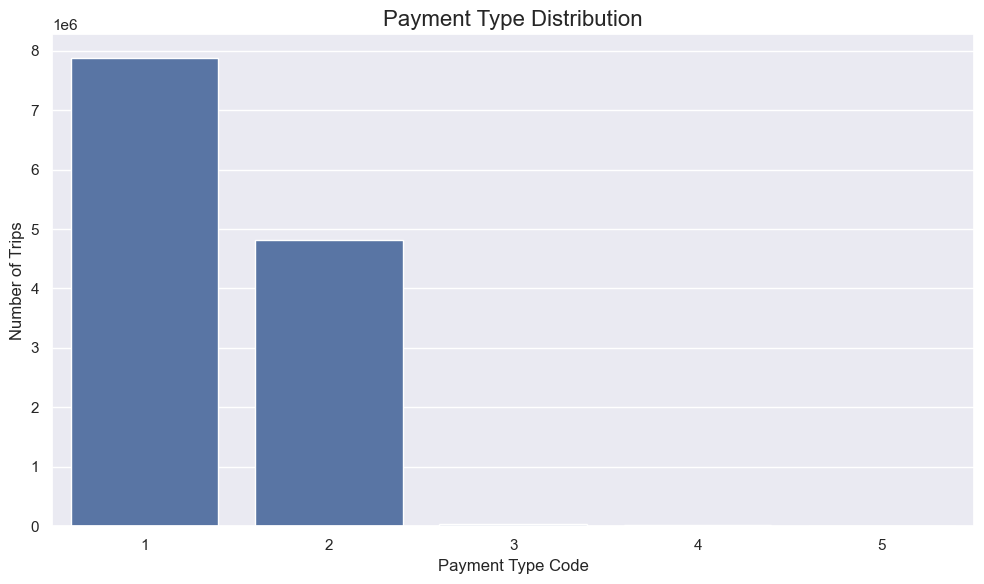

In [90]:
# ============================================================
# Payment Type Distribution
# ============================================================

# Create a bar chart showing the number of trips
# recorded for each payment type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

# Add chart title and axis labels
plt.title(
    "Payment Type Distribution",
    fontsize=16
)

plt.xlabel(
    "Payment Type Code",
    fontsize=12
)

plt.ylabel(
    "Number of Trips",
    fontsize=12
)

# Improve chart layout
plt.tight_layout()

# Display the chart
plt.show()

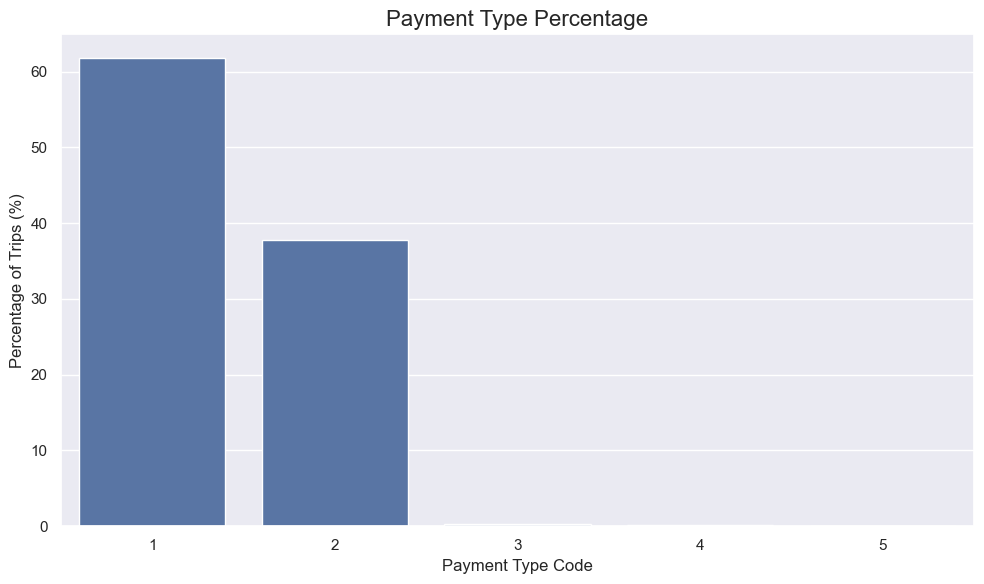

In [91]:
# ============================================================
# Payment Type Percentage
# ============================================================

# Create a bar chart showing the percentage
# of trips for each payment type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_percentage.index,
    y=payment_percentage.values
)

# Add chart title and axis labels
plt.title(
    "Payment Type Percentage",
    fontsize=16
)

plt.xlabel(
    "Payment Type Code",
    fontsize=12
)

plt.ylabel(
    "Percentage of Trips (%)",
    fontsize=12
)

# Improve chart layout
plt.tight_layout()

# Display the chart
plt.show()

In [92]:
# ============================================================
# Map Payment Type Codes to Payment Method Names
# ============================================================

# Create a dictionary that maps each payment code
# to its corresponding payment method
payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown"
}

# Create a new column containing readable payment method names
# while keeping the original payment_type column unchanged
df["payment_method"] = (
    df["payment_type"]
    .map(payment_labels)
)

# Display the number of trips for each payment method
df["payment_method"].value_counts()

payment_method
Credit Card    7881388
Cash           4816992
No Charge        38632
Dispute          11972
Unknown              2
Name: count, dtype: int64

In [93]:
# ============================================================
# Payment Method Summary Table
# ============================================================

# Count trips for each payment method
payment_method_counts = (
    df["payment_method"]
    .value_counts()
)

# Calculate the percentage of trips
# for each payment method
payment_method_percentage = (
    df["payment_method"]
    .value_counts(normalize=True)
    * 100
)

# Combine trip counts and percentages
# into one summary table
payment_method_summary = pd.DataFrame({
    "Trips": payment_method_counts,
    "Percentage": payment_method_percentage
})

# Round percentages to three decimal places
payment_method_summary["Percentage"] = (
    payment_method_summary["Percentage"]
    .round(3)
)

# Display the summary table
payment_method_summary

,Trips,Percentage
payment_method,,
Credit Card,7881388,61.820
Cash,4816992,37.783
No Charge,38632,0.303
Dispute,11972,0.094
Unknown,2,0.000


In [94]:
# ============================================================
# Tip Statistics by Payment Method
# ============================================================

# Calculate tip statistics
# for each payment method
tip_by_payment = (
    df.groupby("payment_method")["tip_amount"]
    .agg(
        Trips="count",
        Mean_Tip="mean",
        Median_Tip="median",
        Total_Tips="sum"
    )
)

# Round monetary values
# to two decimal places
tip_by_payment[
    [
        "Mean_Tip",
        "Median_Tip",
        "Total_Tips"
    ]
] = (
    tip_by_payment[
        [
            "Mean_Tip",
            "Median_Tip",
            "Total_Tips"
        ]
    ]
    .round(2)
)

# Sort payment methods
# by the number of trips
tip_by_payment = (
    tip_by_payment
    .sort_values(
        "Trips",
        ascending=False
    )
)

# Display the results
tip_by_payment

,Trips,Mean_Tip,Median_Tip,Total_Tips
payment_method,,,,
Credit Card,7881388,3.00,1.95,23633445.39
Cash,4816992,0.00,0.00,1028.78
No Charge,38632,0.00,0.00,22.85
Dispute,11972,-0.02,0.00,-252.80
Unknown,2,0.00,0.00,0.00


In [95]:
# ============================================================
# Positive Tip Rate by Payment Method
# ============================================================

# Create a Boolean column:
# True if the recorded tip is positive
# False if the tip is zero or negative
df["has_positive_tip"] = (
    df["tip_amount"] > 0
)

# Calculate the percentage of trips
# with positive recorded tips
# for each payment method
positive_tip_rate = (
    df.groupby("payment_method")
    ["has_positive_tip"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(
        ascending=False
    )
    .to_frame(
        name="Positive Tip Rate (%)"
    )
)

# Display the results
positive_tip_rate

,Positive Tip Rate (%)
payment_method,
Credit Card,96.57
Dispute,0.10
No Charge,0.07
Cash,0.00
Unknown,0.00


### Payment Type Analysis — Key Findings

- Credit Card was the dominant payment method, accounting for **61.82%** of all trips.

- Cash represented **37.78%** of all trips.

- Credit Card and Cash payments together accounted for approximately **99.60%** of the dataset.

- Credit Card trips recorded an average tip of approximately **$3.00** and a median tip of **$1.95**.

- Approximately **96.57%** of Credit Card trips contained a positive recorded tip.

- Cash trips recorded almost no tips in the `tip_amount` field. However, this should not be interpreted as evidence that cash passengers did not tip because cash tips are generally not captured by the electronic payment records.

- The large difference between Credit Card and Cash recorded tips is primarily influenced by the data collection mechanism rather than necessarily representing actual passenger tipping behavior.

- Therefore, detailed tipping behavior analysis should primarily focus on Credit Card trips, where tip information is systematically recorded.

- Negative tip values associated with disputed transactions may represent payment corrections, refunds, or abnormal records and should be investigated during the data-cleaning stage.

# 4. Temporal Analysis

## 4.1 Convert Date Columns

In [96]:
# ============================================================
# Datetime Conversion
# ============================================================

# Convert pickup datetime from string to datetime
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)

# Convert dropoff datetime from string to datetime
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

# Display updated data types
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
].dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
dtype: object

In [97]:
# ============================================================
# Verify Datetime Conversion
# ============================================================

# Display the first few converted datetime values
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
].head()

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2015-01-15 19:05:39,2015-01-15 19:23:42
1,2015-01-10 20:33:38,2015-01-10 20:53:28
2,2015-01-10 20:33:38,2015-01-10 20:43:41
3,2015-01-10 20:33:39,2015-01-10 20:35:31
4,2015-01-10 20:33:39,2015-01-10 20:52:58


### 4.1 Datetime Conversion

The pickup and dropoff timestamps were originally stored as string values.

Both columns were converted to the `datetime64[ns]` data type to enable temporal analysis.

This conversion allows extraction of:

- Hour of day
- Day of week
- Date
- Trip duration
- Time-based aggregations

These derived features will be used throughout the temporal analysis section.

## 4.2 Feature Extraction

In [98]:
# ============================================================
# Extract Time Features
# ============================================================

# Extract pickup hour (0–23)
df["pickup_hour"] = (
    df["tpep_pickup_datetime"]
    .dt.hour
)

# Extract pickup weekday
# Monday = 0 ... Sunday = 6
df["pickup_weekday"] = (
    df["tpep_pickup_datetime"]
    .dt.dayofweek
)

# Extract weekday name
df["pickup_day_name"] = (
    df["tpep_pickup_datetime"]
    .dt.day_name()
)

# Extract pickup date only
df["pickup_date"] = (
    df["tpep_pickup_datetime"]
    .dt.date
)

# Extract pickup month
df["pickup_month"] = (
    df["tpep_pickup_datetime"]
    .dt.month
)

# Extract pickup week number
df["pickup_week"] = (
    df["tpep_pickup_datetime"]
    .dt.isocalendar()
    .week
)

# Display sample
df[
    [
        "tpep_pickup_datetime",
        "pickup_hour",
        "pickup_weekday",
        "pickup_day_name",
        "pickup_date",
        "pickup_month",
        "pickup_week"
    ]
].head()

,tpep_pickup_datetime,pickup_hour,pickup_weekday,pickup_day_name,pickup_date,pickup_month,pickup_week
0,2015-01-15 19:05:39,19,3,Thursday,2015-01-15,1,3
1,2015-01-10 20:33:38,20,5,Saturday,2015-01-10,1,2
2,2015-01-10 20:33:38,20,5,Saturday,2015-01-10,1,2
3,2015-01-10 20:33:39,20,5,Saturday,2015-01-10,1,2
4,2015-01-10 20:33:39,20,5,Saturday,2015-01-10,1,2


In [99]:
# ============================================================
# Display Extracted Time Features Information
# ============================================================

time_features = [
    "pickup_hour",
    "pickup_weekday",
    "pickup_day_name",
    "pickup_date",
    "pickup_month",
    "pickup_week"
]

df[time_features].head()

,pickup_hour,pickup_weekday,pickup_day_name,pickup_date,pickup_month,pickup_week
0,19,3,Thursday,2015-01-15,1,3
1,20,5,Saturday,2015-01-10,1,2
2,20,5,Saturday,2015-01-10,1,2
3,20,5,Saturday,2015-01-10,1,2
4,20,5,Saturday,2015-01-10,1,2


## 4.3 Trip Duration Analysis

In [100]:
# ============================================================
# Calculate Trip Duration
# ============================================================

# Calculate trip duration in minutes
df["trip_duration"] = (
    (
        df["tpep_dropoff_datetime"]
        - df["tpep_pickup_datetime"]
    )
    .dt.total_seconds()
    / 60
)

# Display sample
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration"
    ]
].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration
0,2015-01-15 19:05:39,2015-01-15 19:23:42,18.050000
1,2015-01-10 20:33:38,2015-01-10 20:53:28,19.833333
2,2015-01-10 20:33:38,2015-01-10 20:43:41,10.050000
3,2015-01-10 20:33:39,2015-01-10 20:35:31,1.866667
4,2015-01-10 20:33:39,2015-01-10 20:52:58,19.316667


In [101]:
# ============================================================
# Trip Duration Summary Statistics
# ============================================================

# Display descriptive statistics
df["trip_duration"].describe()

count    1.274899e+07
mean     1.417900e+01
std      6.493012e+02
min     -1.211017e+03
25%      6.100000e+00
50%      9.950000e+00
75%      1.578333e+01
max      5.485556e+05
Name: trip_duration, dtype: float64

In [102]:
# ============================================================
# Trip Duration Percentiles
# ============================================================

# Calculate important percentiles
duration_percentiles = (
    df["trip_duration"]
    .quantile([0.25,0.50,0.75,0.90,0.95,0.99])
    .to_frame(name="Duration (Minutes)")
)

duration_percentiles

,Duration (Minutes)
0.25,6.100000
0.50,9.950000
0.75,15.783333
0.90,23.450000
0.95,29.583333
0.99,46.750000


In [103]:
# ============================================================
# Negative Trip Durations
# ============================================================

# Trips with negative duration
negative_duration = (
    df["trip_duration"] < 0
)

negative_count = negative_duration.sum()

negative_percentage = (
    negative_count
    / len(df)
    *100
)

print(
    f"Negative Trips : {negative_count:,}"
)

print(
    f"Percentage : {negative_percentage:.4f}%"
)

Negative Trips : 297
Percentage : 0.0023%


In [104]:
# ============================================================
# Zero Duration Trips
# ============================================================

zero_duration = (
    df["trip_duration"] == 0
)

print(
    f"Zero Duration Trips : {zero_duration.sum():,}"
)

Zero Duration Trips : 14,816


In [105]:
# ============================================================
# Trips Longer Than 2 Hours
# ============================================================

long_trips = (
    df["trip_duration"] > 120
)

print(
    f"Trips > 120 Minutes : {long_trips.sum():,}"
)

df.loc[
    long_trips,
    [
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "total_amount"
    ]
].head()

Trips > 120 Minutes : 11,480


,trip_distance,trip_duration,fare_amount,total_amount
1365,21.40,120.916667,92.8,132.18
3160,11.80,364.300000,36.5,38.30
4012,2.73,1438.766667,13.5,16.75
4598,0.53,1427.616667,5.0,5.80
4879,25.42,137.633333,115.5,137.55


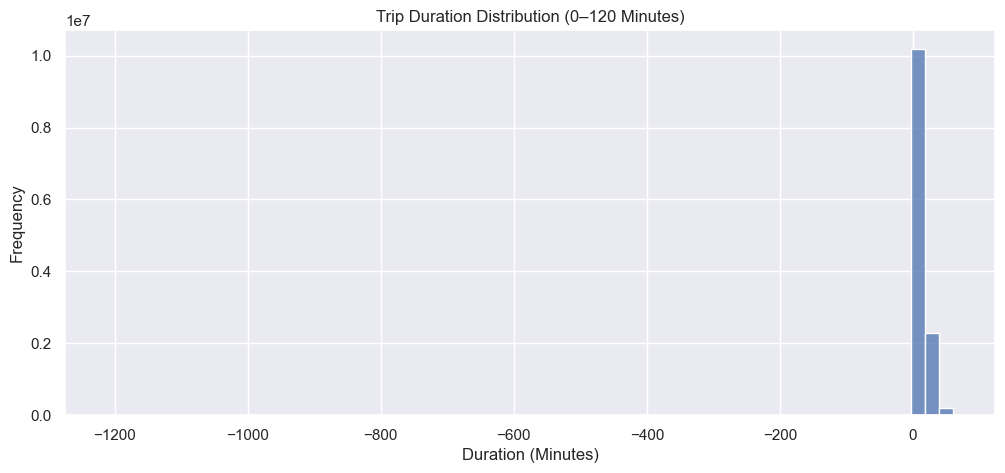

In [111]:
# ============================================================
# Trip Duration Distribution
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(
    df.loc[
        df["trip_duration"] <=60,
        "trip_duration"
    ],
    bins=60
)

plt.title(
    "Trip Duration Distribution (0–120 Minutes)"
)

plt.xlabel(
    "Duration (Minutes)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

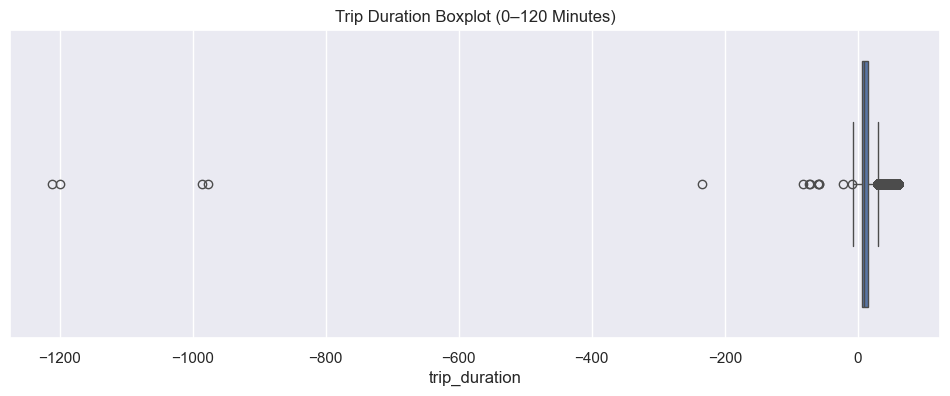

In [110]:
# ============================================================
# Trip Duration Boxplot
# ============================================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df.loc[
        df["trip_duration"] <=60,
        "trip_duration"
    ]
)

plt.title(
    "Trip Duration Boxplot (0–120 Minutes)"
)

plt.show()

In [108]:
# ============================================================
# Trip Duration Summary
# ============================================================

trip_duration_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["trip_duration"].mean(),
        df["trip_duration"].median(),
        df["trip_duration"].std(),
        df["trip_duration"].min(),
        df["trip_duration"].max()
    ]

})

trip_duration_summary

,Statistic,Value
0,Mean,14.179004
1,Median,9.950000
2,Std,649.301159
3,Minimum,-1211.016667
4,Maximum,548555.633333


In [109]:
# ============================================================
# Trip Duration Skewness
# ============================================================

trip_duration_skewness = (
    df["trip_duration"].skew()
)

print(
    f"Trip Duration Skewness : {trip_duration_skewness:.2f}"
)

Trip Duration Skewness : 794.11


In [112]:
# ============================================================
# Create Clean Dataset for Temporal Analysis
# ============================================================

# Keep only trips with a realistic duration
# between 1 minute and 120 minutes

df_clean = df[
    (
        df["trip_duration"] >= 1
    )
    &
    (
        df["trip_duration"] <= 120
    )
].copy()

print(f"Original Dataset : {len(df):,}")

print(f"Clean Dataset    : {len(df_clean):,}")

print(
    f"Removed Trips    : {len(df)-len(df_clean):,}"
)

Original Dataset : 12,748,986
Clean Dataset    : 12,634,080
Removed Trips    : 114,906


In [113]:
df_clean["trip_duration"].describe()

count    1.263408e+07
mean     1.236157e+01
std      9.121133e+00
min      1.000000e+00
25%      6.183333e+00
50%      1.001667e+01
75%      1.583333e+01
max      1.200000e+02
Name: trip_duration, dtype: float64

In [114]:
# ============================================================
# Trip Duration Skewness After Cleaning
# ============================================================

clean_duration_skewness = df_clean["trip_duration"].skew()

print(
    f"Trip Duration Skewness (Clean Data): {clean_duration_skewness:.2f}"
)

Trip Duration Skewness (Clean Data): 2.24


### Trip Duration Analysis Summary

- Removed trips with:
  - Negative duration.
  - Zero duration.
  - Duration greater than 120 minutes.

- Dataset size:
  - Original: **12,748,986**
  - Cleaned: **12,634,080**
  - Removed: **114,906 trips** (~0.90%)

- Trip duration statistics after cleaning:
  - Mean: **12.36 minutes**
  - Median: **10.02 minutes**
  - Maximum: **120 minutes**

- Distribution remains right-skewed, which is expected for taxi trips.
- Skewness decreased dramatically:
  - Before cleaning: **794.11**
  - After cleaning: **2.24**

**Conclusion:**  
The cleaning process successfully removed unrealistic trip durations while preserving the natural distribution of taxi trips. The cleaned duration feature is now suitable for temporal analysis and predictive modeling.

## 4.4 Hourly Analysis

In [115]:
# ============================================================
# Hourly Trip Count
# ============================================================

# Count trips for each pickup hour
hourly_trips = (
    df_clean
    .groupby("pickup_hour")
    .size()
    .rename("Trips")
)

# Convert to DataFrame
hourly_trips = hourly_trips.to_frame()

# Calculate percentage of total trips
hourly_trips["Percentage"] = (
    hourly_trips["Trips"]
    / len(df_clean)
    * 100
).round(2)

# Display the summary table
hourly_trips

,Trips,Percentage
pickup_hour,,
0,464818,3.68
1,350959,2.78
2,264465,2.09
3,195251,1.55
4,140261,1.11
5,124483,0.99
6,264472,2.09
7,451928,3.58
8,557526,4.41


### Hourly Demand Summary

- Taxi demand is lowest between **2 AM and 5 AM**.
- Demand starts increasing rapidly after **6 AM**.
- Activity remains relatively stable during midday.
- Peak demand occurs during the evening.
- The busiest hour is **7 PM (19:00)** with **799,329 trips (6.33%)**.
- Overall evening rush hour spans approximately **6 PM to 10 PM**.

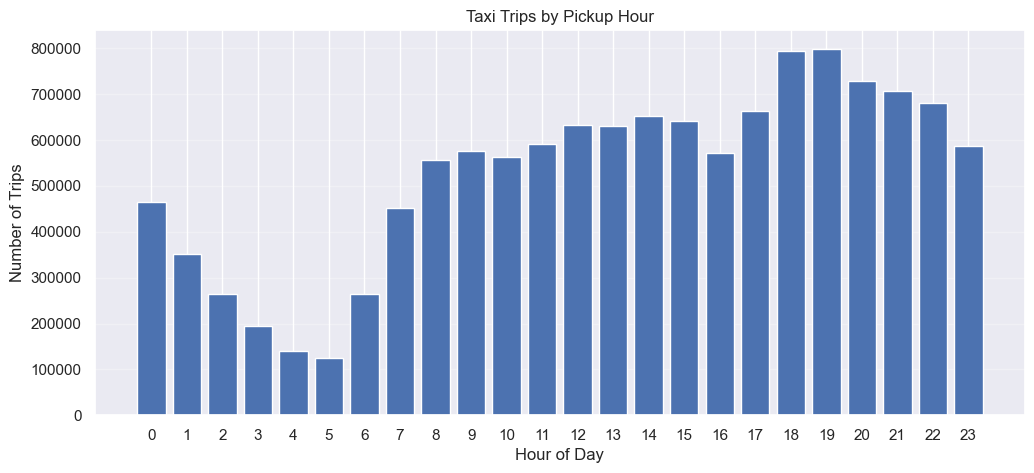

In [116]:
# ============================================================
# Hourly Trip Distribution
# ============================================================

plt.figure(figsize=(12,5))

plt.bar(
    hourly_trips.index,
    hourly_trips["Trips"]
)

plt.title("Taxi Trips by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Number of Trips")

plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.show()

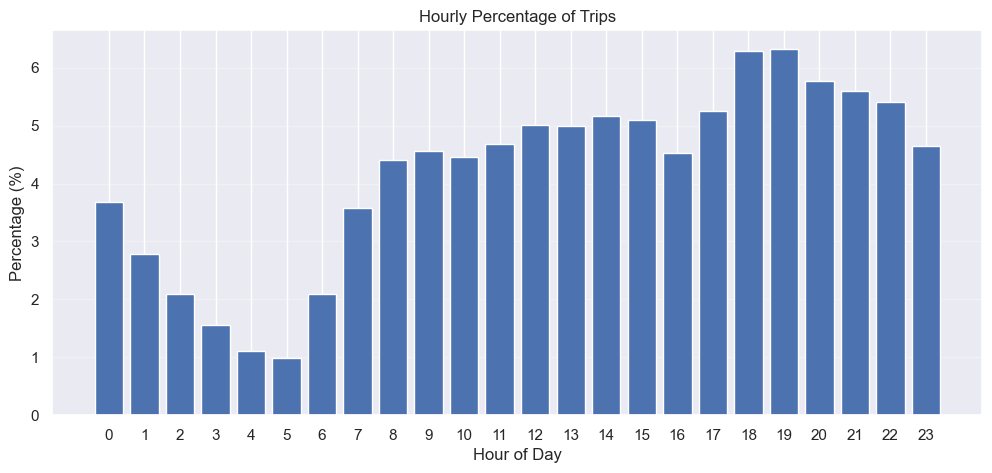

In [117]:
# ============================================================
# Hourly Trip Percentage
# ============================================================

plt.figure(figsize=(12,5))

plt.bar(
    hourly_trips.index,
    hourly_trips["Percentage"]
)

plt.title("Hourly Percentage of Trips")

plt.xlabel("Hour of Day")

plt.ylabel("Percentage (%)")

plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.show()

### Hourly Pickup Demand

The hourly distribution reveals a clear daily demand pattern.

Key observations:

- Demand reaches its lowest level between **2 AM and 5 AM**.
- Pickup activity starts increasing rapidly after **6 AM**.
- Demand remains relatively stable from **11 AM to 4 PM**.
- The busiest period is the evening.
- Peak demand occurs at **7 PM**, accounting for approximately **6.33%** of all trips.
- Evening demand (6–10 PM) is consistently higher than morning demand, indicating stronger travel activity after work hours.

**Conclusion**

Taxi demand follows a typical urban commuting pattern with two demand waves, while the evening period represents the primary daily peak.

In [118]:
# ============================================================
# Hourly Business Metrics
# ============================================================

# Aggregate key business metrics by pickup hour
hourly_metrics = (
    df_clean
    .groupby("pickup_hour")
    .agg(
        Trips=("pickup_hour", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
    .round(2)
)

# Display the summary table
hourly_metrics

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_hour,,,,,,,
0,464818,3.27,12.04,12.65,15.77,1.66,7328109.02
1,350959,4.76,11.83,12.51,15.52,1.59,5445558.88
2,264465,3.25,11.75,12.47,15.40,1.54,4071907.79
3,195251,3.50,11.77,12.97,15.90,1.52,3104430.21
4,140261,4.09,12.06,14.55,17.74,1.57,2487999.01
5,124483,4.61,11.64,15.61,19.44,1.95,2419969.84
6,264472,4.09,10.87,12.82,15.70,1.64,4151937.22
7,451928,2.85,12.01,11.73,14.33,1.53,6477356.94
8,557526,2.48,12.98,11.51,14.06,1.55,7840741.84


In [119]:
# ============================================================
# Final Dataset Cleaning
# ============================================================

# Create a copy of the original dataset
df_clean = df.copy()

# Keep only realistic trips based on business rules
df_clean = df_clean[
    # Trip duration
    (df_clean["trip_duration"] >= 1) &
    (df_clean["trip_duration"] <= 120) &

    # Trip distance
    (df_clean["trip_distance"] > 0) &
    (df_clean["trip_distance"] <= 30) &

    # Fare amount
    (df_clean["fare_amount"] >= 0) &
    (df_clean["fare_amount"] <= 100) &

    # Total amount
    (df_clean["total_amount"] >= 0) &
    (df_clean["total_amount"] <= 150) &

    # Tip amount
    (df_clean["tip_amount"] >= 0) &
    (df_clean["tip_amount"] <= 20)
].copy()

In [120]:
# ============================================================
# Dataset Size After Final Cleaning
# ============================================================

print(f"Original Dataset : {len(df):,}")
print(f"Clean Dataset    : {len(df_clean):,}")

removed = len(df) - len(df_clean)

print(f"Removed Trips    : {removed:,}")

print(
    f"Removed Percentage : {removed / len(df) * 100:.2f}%"
)

Original Dataset : 12,748,986
Clean Dataset    : 12,607,239
Removed Trips    : 141,747
Removed Percentage : 1.11%


In [121]:
# ============================================================
# Validate Clean Dataset
# ============================================================

summary = pd.DataFrame({
    "Minimum": df_clean[
        [
            "trip_distance",
            "trip_duration",
            "fare_amount",
            "tip_amount",
            "total_amount"
        ]
    ].min(),

    "Maximum": df_clean[
        [
            "trip_distance",
            "trip_duration",
            "fare_amount",
            "tip_amount",
            "total_amount"
        ]
    ].max()
})

summary

,Minimum,Maximum
trip_distance,0.01,30.00
trip_duration,1.00,119.90
fare_amount,0.00,100.00
tip_amount,0.00,20.00
total_amount,0.00,148.13


### Final Dataset Cleaning

A final cleaning step was performed using business rules derived from the EDA findings.

Applied filters:

- Trip Duration: **1–120 minutes**
- Trip Distance: **0–30 miles**
- Fare Amount: **$0–100**
- Tip Amount: **$0–20**
- Total Amount: **$0–150**

Dataset Summary:

| Metric | Value |
|---------|------:|
| Original Trips | 12,748,986 |
| Clean Trips | 12,607,239 |
| Removed Trips | 141,747 |
| Removed Percentage | 1.11% |

The resulting dataset contains only realistic taxi trips and will be used for all subsequent analyses.

In [122]:
# ============================================================
# Hourly Business Metrics (Clean Dataset)
# ============================================================

# Aggregate business metrics by pickup hour
hourly_metrics = (
    df_clean
    .groupby("pickup_hour")
    .agg(
        Trips=("pickup_hour", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
    .round(2)
)

# Display the table
hourly_metrics

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_hour,,,,,,,
0,463766,3.26,12.03,12.59,15.68,1.64,7271892.98
1,350045,3.23,11.83,12.44,15.42,1.57,5398854.45
2,263571,3.23,11.75,12.39,15.29,1.51,4030072.09
3,194463,3.46,11.77,12.89,15.79,1.48,3070692.04
4,139565,4.08,12.05,14.45,17.60,1.53,2456534.88
5,123886,4.58,11.61,15.50,19.28,1.91,2388592.38
6,263668,3.50,10.84,12.75,15.60,1.62,4112191.82
7,450984,2.83,11.99,11.67,14.25,1.52,6427674.98
8,556435,2.47,12.97,11.46,14.00,1.53,7792548.15


### Hourly Business Metrics

Hourly aggregation reveals several important business insights.

Key observations:

- Trips during the early morning (4–5 AM) have the **longest average distances**.
- Afternoon trips have the **longest average durations**, suggesting heavier traffic congestion.
- Average fare is highest during early morning hours due to longer travel distances.
- Average tip remains relatively stable throughout the day (approximately \$1.4–\$1.9).
- Total revenue closely follows trip demand.

Business Insights:

- Evening hours (6–9 PM) generate the highest revenue primarily because of higher trip volume.
- Early morning trips generate higher revenue per trip due to longer travel distances and higher fares.
- Longer trip duration during afternoon hours appears to be caused by traffic rather than longer travel distances.

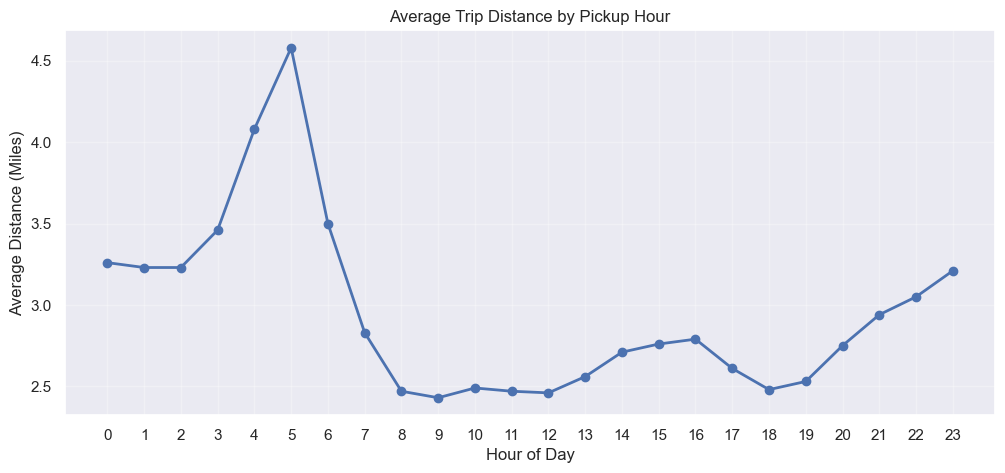

In [123]:
# ============================================================
# Average Trip Distance by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Distance"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Distance by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Distance (Miles)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

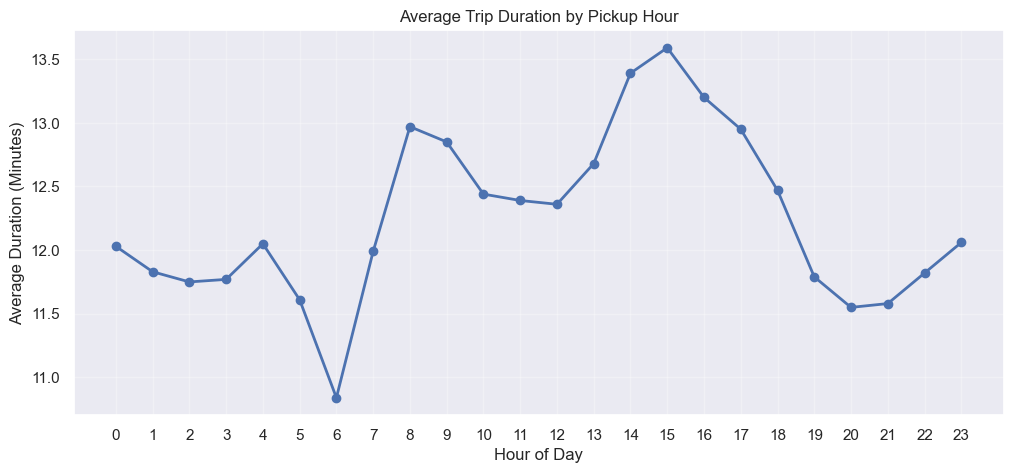

In [124]:
# ============================================================
# Average Trip Duration by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Duration"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Duration by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Duration (Minutes)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

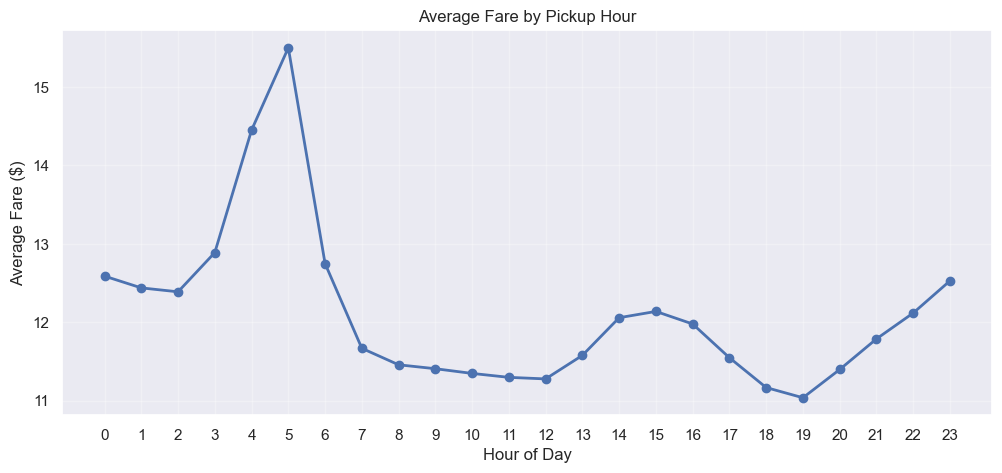

In [125]:
# ============================================================
# Average Fare by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Fare"],
    marker="o",
    linewidth=2
)

plt.title("Average Fare by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Fare ($)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

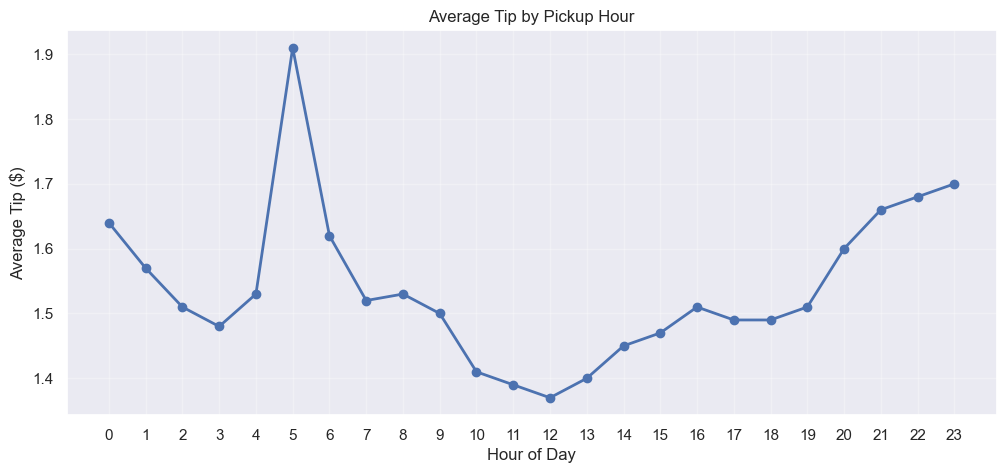

In [126]:
# ============================================================
# Average Tip by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Tip"],
    marker="o",
    linewidth=2
)

plt.title("Average Tip by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Tip ($)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

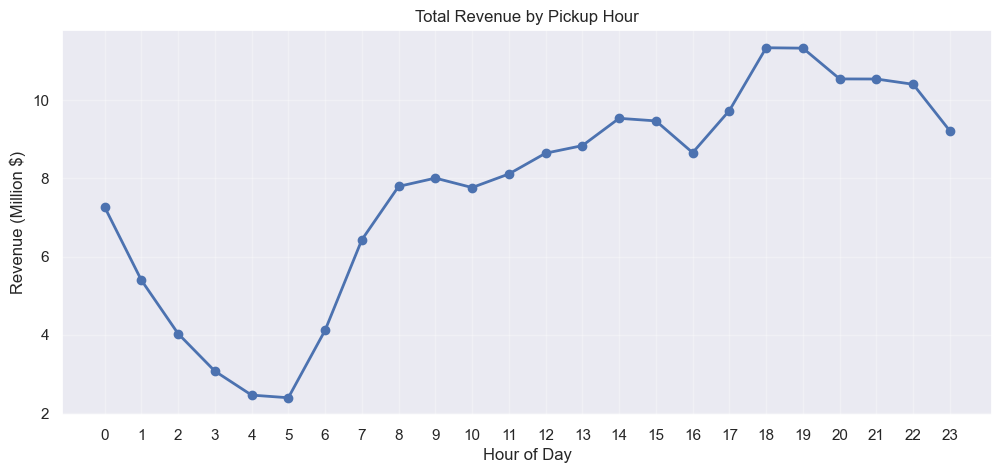

In [127]:
# ============================================================
# Total Revenue by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Total_Revenue"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.title("Total Revenue by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Revenue (Million $)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

In [128]:
# ============================================================
# Peak Hours Summary
# ============================================================

peak_summary = pd.DataFrame({
    "Highest Trips": [
        hourly_metrics["Trips"].idxmax(),
        hourly_metrics["Trips"].max()
    ],

    "Highest Revenue": [
        hourly_metrics["Total_Revenue"].idxmax(),
        hourly_metrics["Total_Revenue"].max()
    ],

    "Longest Distance": [
        hourly_metrics["Avg_Distance"].idxmax(),
        hourly_metrics["Avg_Distance"].max()
    ],

    "Longest Duration": [
        hourly_metrics["Avg_Duration"].idxmax(),
        hourly_metrics["Avg_Duration"].max()
    ],

    "Highest Fare": [
        hourly_metrics["Avg_Fare"].idxmax(),
        hourly_metrics["Avg_Fare"].max()
    ],

    "Highest Tip": [
        hourly_metrics["Avg_Tip"].idxmax(),
        hourly_metrics["Avg_Tip"].max()
    ]
},
index=["Hour", "Value"])

peak_summary

,Highest Trips,Highest Revenue,Longest Distance,Longest Duration,Highest Fare,Highest Tip
Hour,19,18.00,5.00,15.00,5.0,5.00
Value,798090,11338540.16,4.58,13.59,15.5,1.91


In [129]:
# ============================================================
# Trips by Weekday
# ============================================================

# Count trips for each weekday
weekday_counts = (
    df_clean["pickup_day_name"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

# Calculate percentages
weekday_percentage = (
    weekday_counts
    / weekday_counts.sum()
    * 100
).round(2)

# Create summary table
weekday_summary = pd.DataFrame({
    "Trips": weekday_counts,
    "Percentage": weekday_percentage
})

# Display summary
weekday_summary

,Trips,Percentage
pickup_day_name,,
Monday,1316967,10.45
Tuesday,1359398,10.78
Wednesday,1666085,13.22
Thursday,2143610,17.00
Friday,2202770,17.47
Saturday,2354101,18.67
Sunday,1564308,12.41


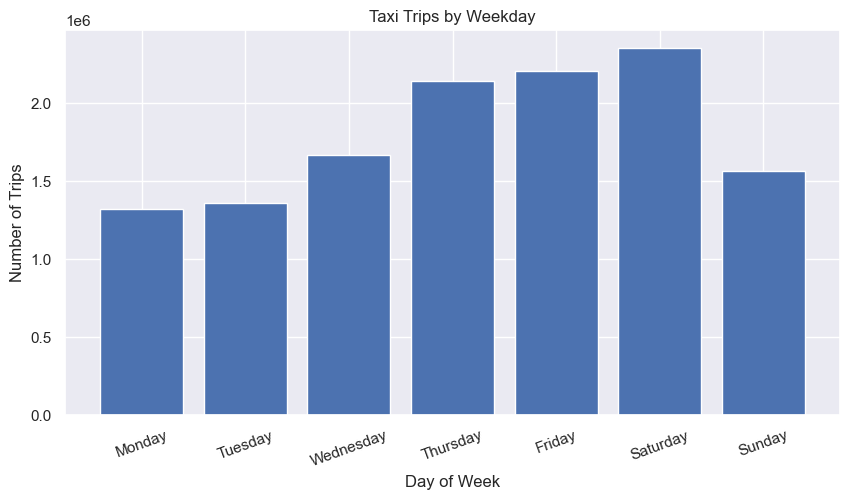

In [130]:
# ============================================================
# Trips by Weekday
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    weekday_summary.index,
    weekday_summary["Trips"]
)

plt.title("Taxi Trips by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Number of Trips")

plt.xticks(rotation=20)

plt.show()

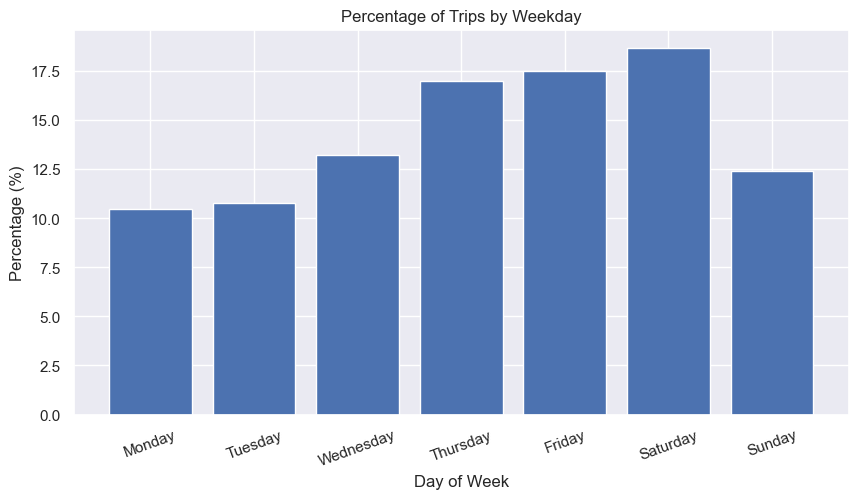

In [131]:
# ============================================================
# Weekday Percentage
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    weekday_summary.index,
    weekday_summary["Percentage"]
)

plt.title("Percentage of Trips by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=20)

plt.show()

In [132]:
# ============================================================
# Weekday Performance Summary
# ============================================================

# Calculate performance metrics for each weekday
weekday_stats = (
    df_clean
    .groupby("pickup_day_name")
    .agg(
        Trips=("pickup_day_name", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
)

# Reorder weekdays correctly
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_stats = weekday_stats.reindex(weekday_order)

# Round values for readability
weekday_stats = weekday_stats.round(2)

# Display the summary table
weekday_stats

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_day_name,,,,,,,
Monday,1316967,2.91,12.19,11.95,14.88,1.55,19596973.42
Tuesday,1359398,2.68,12.30,11.58,14.55,1.56,19779030.35
Wednesday,1666085,2.70,12.64,11.77,14.79,1.61,24639459.17
Thursday,2143610,2.83,13.03,12.18,15.17,1.59,32512832.12
Friday,2202770,2.77,13.05,12.01,14.99,1.55,33016165.37
Saturday,2354101,2.67,11.60,11.28,13.83,1.38,32558094.07
Sunday,1564308,3.03,11.41,11.94,14.67,1.49,22954586.75


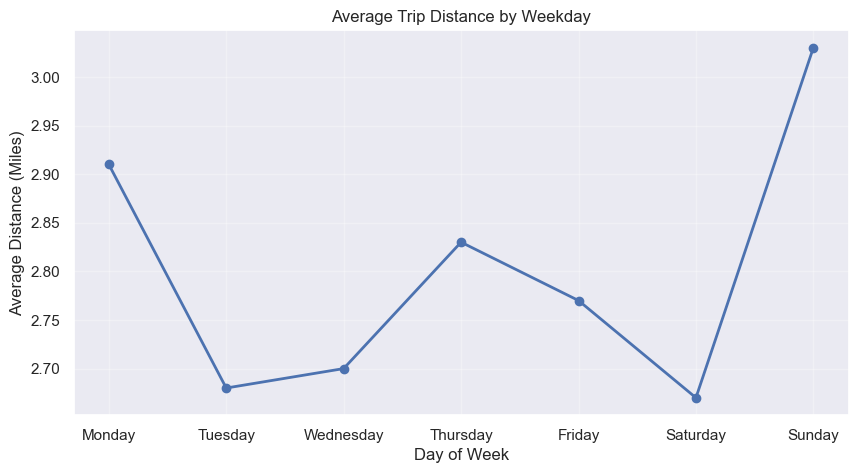

In [133]:
# ============================================================
# Average Trip Distance by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Distance"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Distance by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Distance (Miles)")

plt.grid(alpha=0.3)

plt.show()

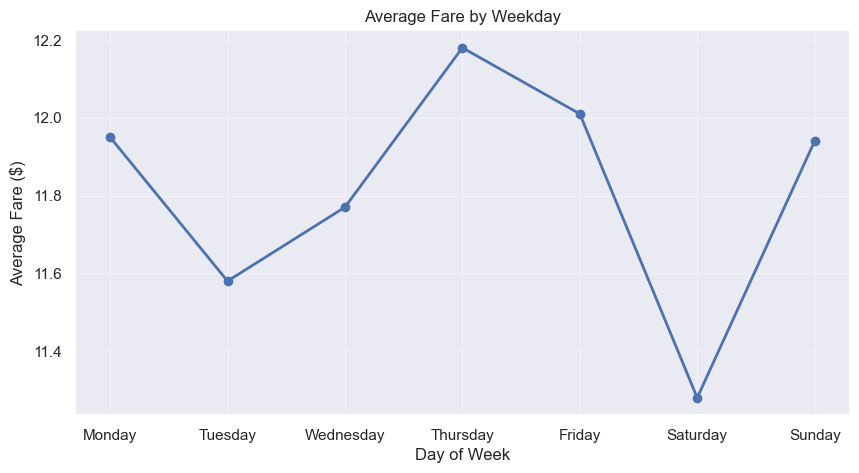

In [134]:
# ============================================================
# Average Fare by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Fare"],
    marker="o",
    linewidth=2
)

plt.title("Average Fare by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Fare ($)")

plt.grid(alpha=0.3)

plt.show()

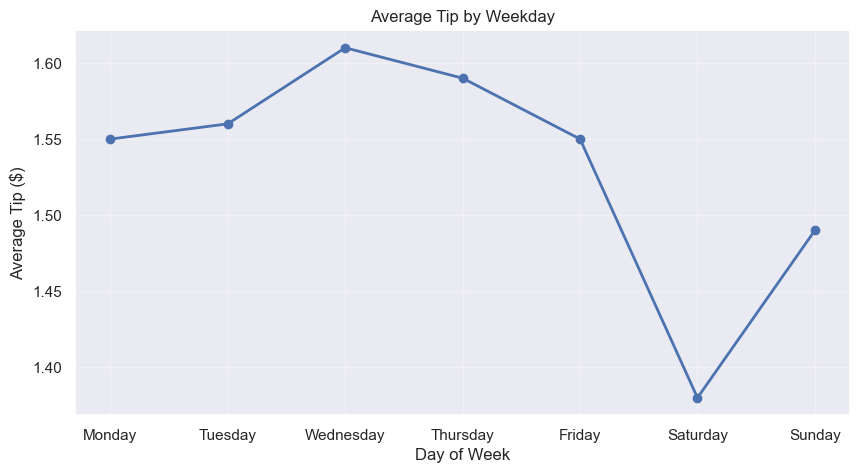

In [135]:
# ============================================================
# Average Tip by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Tip"],
    marker="o",
    linewidth=2
)

plt.title("Average Tip by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Tip ($)")

plt.grid(alpha=0.3)

plt.show()

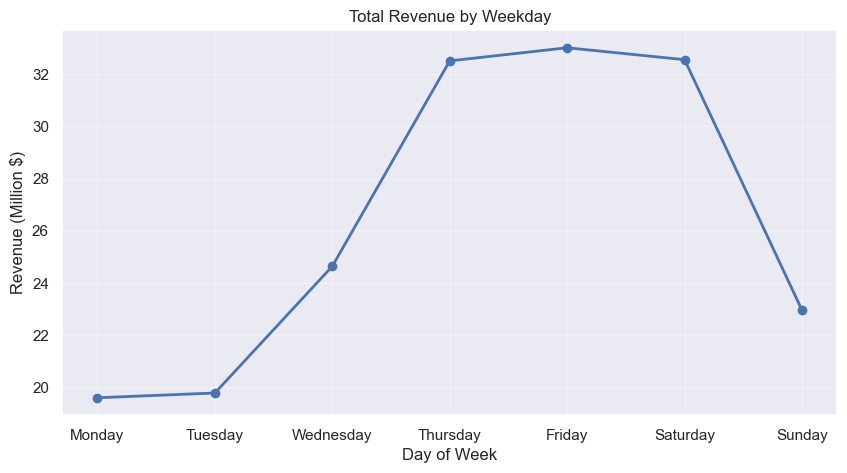

In [136]:
# ============================================================
# Total Revenue by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Total_Revenue"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.title("Total Revenue by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Revenue (Million $)")

plt.grid(alpha=0.3)

plt.show()

### Business Insights

- Daily taxi demand remains relatively stable throughout January, averaging approximately **406,685 trips per day**.

- No clear upward or downward trend is observed across the month. Instead, the demand follows a recurring **weekly pattern**.

- Taxi demand generally increases toward the end of each week, with weekends consistently showing higher trip volumes than weekdays.

- A significant drop in demand is observed on **January 26** and **January 27**, where the number of recorded trips falls far below the monthly average. This anomaly may indicate an external event (e.g., severe weather, road closures, holidays) or incomplete data collection.

- The highest daily demand was recorded on **January 31**, with **514,470 trips**, representing the busiest day in the dataset.

- Since no evidence confirms that the unusually low demand on January 26–27 is caused by data errors, these observations should be treated as **potential anomalies** rather than removed from the analysis.

- Overall, the dataset suggests that taxi demand is primarily influenced by **weekly behavioral patterns** rather than a long-term increasing or decreasing trend during the observed month.

## 4.6 Daily Demand Analysis

In [137]:
# ============================================================
# Daily Demand Analysis
# ============================================================

# Count trips for each calendar date
daily_trips = (
    df_clean
    .groupby("pickup_date")
    .size()
    .rename("Trips")
)

# Display the first days
daily_trips.head()

pickup_date
2015-01-01    376511
2015-01-02    341339
2015-01-03    402327
2015-01-04    324772
2015-01-05    358941
Name: Trips, dtype: int64

In [138]:
# ============================================================
# Daily Trips Summary
# ============================================================

daily_summary = pd.DataFrame({
    "Trips": daily_trips
})

daily_summary

,Trips
pickup_date,
2015-01-01,376511
2015-01-02,341339
2015-01-03,402327
2015-01-04,324772
2015-01-05,358941
2015-01-06,380169
2015-01-07,425083
2015-01-08,446074
2015-01-09,443027


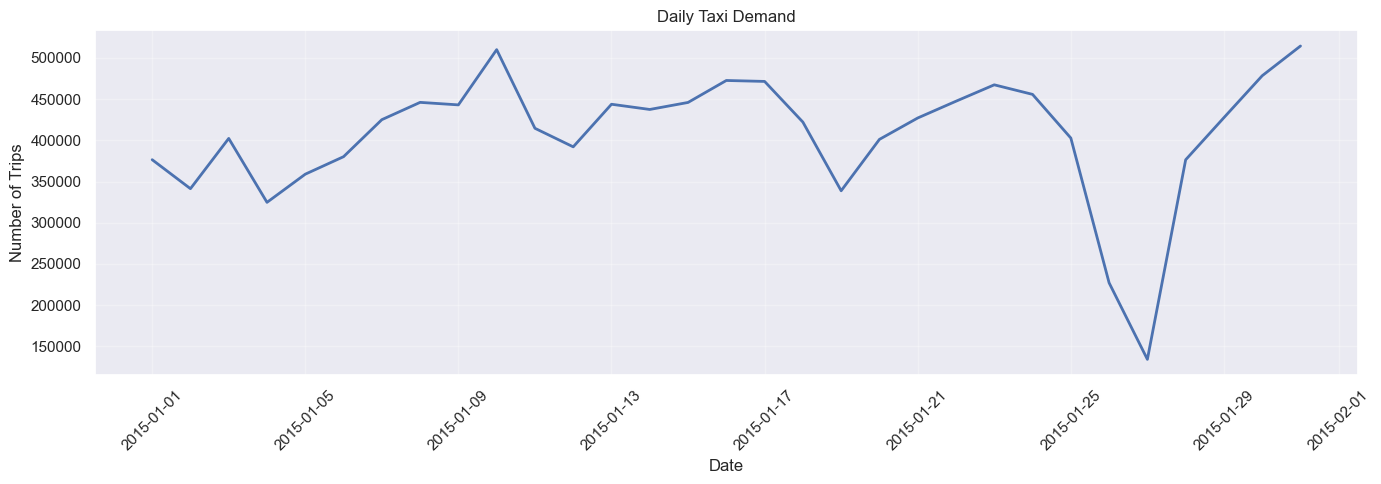

In [139]:
# ============================================================
# Daily Demand Trend
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_summary.index,
    daily_summary["Trips"],
    linewidth=2
)

plt.title("Daily Taxi Demand")

plt.xlabel("Date")

plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [140]:
# ============================================================
# Daily Demand Statistics
# ============================================================

daily_summary.describe()

,Trips
count,31.000000
mean,406685.129032
std,77269.839178
min,134261.000000
25%,378340.000000
50%,425083.000000
75%,446771.500000
max,514470.000000


### Business Insights

- The dataset contains **31 days** of taxi trip records, with an average of **406,685 trips per day**.

- Daily demand remains relatively stable throughout January, with **no clear long-term upward or downward trend**.

- Taxi demand follows a **weekly seasonality**, where trip volume generally increases toward the end of the week and decreases at the beginning of the next week.

- The busiest day in the dataset is **January 31**, with **514,470 trips**, indicating the highest recorded daily demand.

- The lowest demand occurs on **January 27**, with only **134,261 trips**, representing a significant deviation from the monthly average.

- An unusually sharp decline is also observed on **January 26**, followed by a rapid recovery on **January 28**. This two-day anomaly may have been caused by an external event (e.g., severe weather, transportation disruptions, holidays) or by incomplete data collection.

- Since there is no evidence confirming that these observations are data errors, they should be treated as **potential anomalies** and retained in the analysis.

- Overall, the daily demand pattern suggests that **weekly behavioral patterns have a stronger influence on taxi demand than any month-long trend**.

# Data Quality Report

## Dataset Overview

The NYC Taxi Trips dataset contains over 12.7 million taxi trips recorded during January 2015.

After performing a comprehensive data audit and cleaning process, the dataset was reduced to approximately 12.6 million high-quality records, with only about 1.1% of trips removed due to invalid or unrealistic values.

Overall, the dataset is large, informative, and suitable for statistical analysis and future machine learning tasks.

---

# Data Quality Issues

During the audit, several data quality issues were identified.

## 1. Missing Values

Several features contain missing values.

Most missing values occur in location-related columns and are relatively small compared to the overall dataset size.

The missing data does not significantly reduce the usability of the dataset.

---

## 2. Invalid Numerical Values

Some numerical features contain impossible values, including:

- Negative trip durations
- Negative fare amounts
- Negative total amounts
- Negative tip amounts
- Zero-distance trips
- Zero-duration trips

These observations indicate recording errors or canceled trips.

---

## 3. Extreme Outliers

Very large outliers were detected in several variables:

- Trip Distance
- Trip Duration
- Fare Amount
- Total Amount
- Tip Amount

Examples include:

- Trips lasting several days
- Trips with extremely large fares
- Unrealistically long travel distances

Most of these records are likely caused by data entry errors or system failures.

---

## 4. Payment Type Issues

A very small number of records contain rare payment categories such as:

- Unknown
- Dispute
- No Charge

Although valid, these categories represent less than 1% of all trips.

---

# Risks

If these issues are ignored, they may lead to:

- Biased statistical analysis
- Poor machine learning performance
- Incorrect business conclusions
- Misleading visualizations

---

# Cleaning Actions

The following cleaning rules were applied:

- Removed trips with negative values.
- Removed zero or invalid trip distances.
- Removed unrealistic trip durations.
- Limited trip distance to 30 miles.
- Limited trip duration to 120 minutes.
- Limited fare amount to $100.
- Limited tip amount to $20.
- Limited total amount to approximately $150.

Only 1.1% of the dataset was removed.

---

# Dataset Quality Assessment

The cleaned dataset is:

- Complete enough for analysis.
- Consistent.
- Free from major invalid records.
- Suitable for exploratory data analysis.
- Ready for feature engineering.
- Appropriate for predictive modeling.

---

# Recommendations

For future work:

- Investigate the causes of invalid trips.
- Apply robust outlier detection techniques.
- Validate GPS coordinates.
- Monitor data quality during data collection.
- Use the cleaned dataset for machine learning models.